# BlackJAX SMC beam-inference analysis

This notebook is a refactored analysis-only notebook for the MWA dipole-beam
inference. No inference is performed here. The analysis proceeds as follows:

1. load the canonical data, likelihood pixels, and AEE forward model;
2. define the amplitude-only and complex-gain parameterizations;
3. derive the conjugate-rotation symmetry and deterministic branch statistic;
4. inspect the BlackJAX adaptive-tempered SMC diagnostics;
5. analyse the amplitude-only posterior;
6. analyse the complex posterior by the \(S>0\) and \(S<0\) symmetry branches;
7. compare SMC branch masses with the independent local Laplace estimate;
8. examine branch-conditioned power beams and possible symmetry breaking;
9. fold onto a common branch only when a symmetry-reduced parameter summary is desired;
10. compare nominal, amplitude-only, and complex beam models;
11. test temporal robustness with independent 20-day chunks.

## 1. Imports and result file


In [1]:
from pathlib import Path
import pickle

import numpy as np
import healpy as hp
import jax
import jax.numpy as jnp

import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable


from mwa_jaxbeam import aee_137mhz as aee

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
prd = ListedColormap(colors, name="pride")
prd.set_under("white")

wfr_div = cmr.wildfire.with_extremes(under="w")
wfr_lin = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1.0).with_extremes(under="w")

MODE_COLORS = cmr.wildfire([0.2, 0.8])

In [2]:
RESULT_PATH = Path("../data/smc_nuts_blackjax/soft_laplace/S06XX/S06XX_rf0XX_passes_S06XX_N4028_S314159_C200_I0_AMP_COMPLEX_smc_blackjax.pkl")
OUTDIR_PATH = Path("../data/smc_nuts_blackjax/soft_laplace/S06XX/plots")
OUTDIR_PATH.mkdir(parents=True, exist_ok=True)

with RESULT_PATH.open("rb") as handle:
    result = pickle.load(handle)

metadata = result["metadata"]
data = result["data"]
nominal_result = result["nominal"]
amplitude_result = result["amplitude"]
complex_result = result["complex"]

tilepol = f"{metadata['tile']}{metadata['polarization']}"

print("Dataset")
print("-------")
for key in (
    "tile",
    "polarization",
    "chunk_index",
    "chunk_days",
    "nside",
    "dirichlet_alpha",
    "phase_prior_std_deg",
    "seed",
    "n_particles",
    "n_devices",
    "particles_per_device",
):
    print(f"{key:24s}: {metadata[key]}")

print(f"{'amplitude particles':24s}: {np.asarray(amplitude_result['particles']).shape[0]}")
print(f"{'complex particles':24s}: {np.asarray(complex_result['particles']).shape[0]}")
print(f"{'amplitude logZ':24s}: {float(amplitude_result['log_evidence']):.6f}")
print(f"{'complex logZ':24s}: {float(complex_result['log_evidence']):.6f}")

print("\nSingle Pass Low Uncertainity Cuts:")
print(metadata['single_pass_uncertainty_cut'])
print(metadata['n_single_pass_masked'])

Dataset
-------
tile                    : S06
polarization            : XX
chunk_index             : 0
chunk_days              : 200.0
nside                   : 32
dirichlet_alpha         : 10.0
phase_prior_std_deg     : 10.0
seed                    : 314159
n_particles             : 4028
n_devices               : 38
particles_per_device    : 106
amplitude particles     : 4028
complex particles       : 4028
amplitude logZ          : -41132.088246
complex logZ            : -37214.941668

Single Pass Low Uncertainity Cuts:
{'enabled': True, 'robust_z_cut': -3.0, 'pooled_n_single_pass_pixels': 48, 'median_log10_sigma': -0.3167732329502157, 'robust_sigma_log10_sigma': 0.24303253988420306, 'sigma_cut_db': 0.08997651074843022}
0


## 2. Canonical data and likelihood pixels

The pickle stores the full HEALPix data/error maps and the exact comparison-pixel indices used during inference. These are the canonical arrays for every model comparison below.


In [3]:
data_map = np.asarray(data["data_map"], dtype=float)
error_map = np.asarray(data["error_map"], dtype=float)
comparison_indices = np.asarray(data["comparison_indices"], dtype=int)
full_data_map = data_map.copy()


observed_db = data_map[comparison_indices]
observed_sigma_db = error_map[comparison_indices]

NSIDE = int(metadata["nside"])
N_DIPOLES = 16
N_PIXELS = hp.nside2npix(NSIDE)
dipoles = np.arange(N_DIPOLES)

if data_map.shape != (N_PIXELS,):
    raise ValueError(f"Unexpected data-map shape: {data_map.shape}")
if not np.all(np.isfinite(observed_db)):
    raise ValueError("Likelihood data contain non-finite values.")
if not np.all(np.isfinite(observed_sigma_db) & (observed_sigma_db > 0)):
    raise ValueError("Likelihood uncertainties must be finite and positive.")

print("Canonical likelihood data")
print("-------------------------")
print(f"HEALPix pixels:       {N_PIXELS}")
print(f"Comparison pixels:    {comparison_indices.size}")
print(f"Finite data pixels:   {np.count_nonzero(np.isfinite(data_map))}")
print(f"Median uncertainty:   {np.median(observed_sigma_db):.4f} dB")

Canonical likelihood data
-------------------------
HEALPix pixels:       12288
Comparison pixels:    6072
Finite data pixels:   6195
Median uncertainty:   0.3854 dB


In [4]:
def plot_healpix_map(
    healpix_map,
    *,
    fig,
    sub,
    title="",
    unit="",
    vmin=None,
    vmax=None,
    cmap=None,
    badcolor="whitesmoke",
    add_graticule=True,
    add_cardinals=True,
    cardinal_color="white",
):
    healpix_map = np.asarray(healpix_map)
    axes_before = set(fig.axes)

    hp.orthview(
        map=healpix_map,
        fig=fig,
        sub=sub,
        rot=(0, 90, 180),
        half_sky=True,
        min=vmin,
        max=vmax,
        title=title,
        unit=unit,
        badcolor=badcolor,
        cmap=cmap,
        notext=True,
    )

    if add_graticule:
        hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

    if add_cardinals:
        kwargs = {"color": cardinal_color, "fontweight": "light"}
        hp.projtext(np.deg2rad(80), np.deg2rad(90), r"$E$", verticalalignment="top", **kwargs)
        hp.projtext(np.deg2rad(80), np.deg2rad(0), r"$N$", horizontalalignment="right", **kwargs)
        hp.projtext(np.deg2rad(80), np.deg2rad(270), r"$W$", verticalalignment="bottom", **kwargs)
        hp.projtext(np.deg2rad(80), np.deg2rad(180), r"$S$", horizontalalignment="left", **kwargs)

    new_axes = [ax for ax in fig.axes if ax not in axes_before]
    return new_axes[0]


def comparison_values_to_healpix(values):
    values = np.asarray(values, dtype=float)
    if values.shape != comparison_indices.shape:
        raise ValueError(f"Expected {comparison_indices.shape}, received {values.shape}.")
    healpix_map = np.full(data_map.shape, np.nan, dtype=float)
    healpix_map[comparison_indices] = values
    return healpix_map


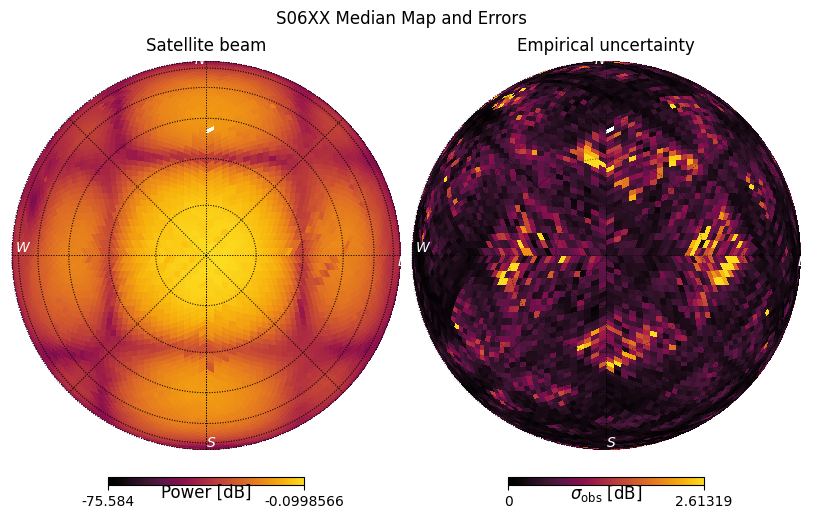

In [5]:
fig = plt.figure(figsize=(8, 5.3))
plot_healpix_map(
    data_map,
    fig=fig,
    sub=(1, 2, 1),
    title="Satellite beam",
    unit="Power [dB]",
    cmap=wfr_lin,
)
plot_healpix_map(
    error_map,
    fig=fig,
    sub=(1, 2, 2),
    title="Empirical uncertainty",
    unit=r"$\sigma_{\rm obs}$ [dB]",
    vmin=0,
    vmax=np.nanpercentile(error_map, 99),
    cmap=wfr_lin,
)
fig.suptitle(f"{tilepol} Median Map and Errors")
plt.savefig(f"{OUTDIR_PATH}/{tilepol}_1_map_errors.pdf")
plt.show()

## 3. Reconstruct the AEE forward model

Posterior beam populations are intentionally not stored in the pickle. The exact forward model used during inference is reconstructed here, and posterior beams are evaluated later in batches only when needed.


In [6]:
pixel_indices = np.arange(N_PIXELS)
za_hpx, az_hpx = hp.pix2ang(NSIDE, pixel_indices)
visible = za_hpx <= np.pi / 2
visible_indices = np.flatnonzero(visible)

visible_lookup = np.full(N_PIXELS, -1, dtype=np.int32)
visible_lookup[visible_indices] = np.arange(visible_indices.size, dtype=np.int32)
comparison_visible_indices = visible_lookup[comparison_indices]

if np.any(comparison_visible_indices < 0):
    raise ValueError("At least one comparison pixel lies outside the visible hemisphere.")

az_visible = jnp.asarray(az_hpx[visible], dtype=jnp.float32)
za_visible = jnp.asarray(za_hpx[visible], dtype=jnp.float32)
comparison_visible_indices_jax = jnp.asarray(comparison_visible_indices, dtype=jnp.int32)
POL = int(metadata["pol_index"])

@jax.jit
def predict_beam_db(dipole_gains_pol):
    fixed = jnp.ones(N_DIPOLES, dtype=jnp.complex64)
    dipole_gains_pol = dipole_gains_pol.astype(jnp.complex64)

    dipole_gains = (
        jnp.stack([dipole_gains_pol, fixed])
        if POL == 0
        else jnp.stack([fixed, dipole_gains_pol])
    )

    power = aee.power(
        az_rad=az_visible,
        za_rad=za_visible,
        dipole_gains=dipole_gains,
        normalize=True,
    )[POL, comparison_visible_indices_jax]

    power = jnp.maximum(
        power,
        jnp.finfo(power.dtype).tiny,
    )

    return 10 * jnp.log10(power)

predict_beam_batch_db = jax.jit(jax.vmap(predict_beam_db, in_axes=0))

nominal_model_db = np.asarray(
    predict_beam_db(jnp.ones(N_DIPOLES, dtype=jnp.complex64)),
    dtype=float,
)
print("Nominal model shape:", nominal_model_db.shape)

Nominal model shape: (6072,)


### Analysis helpers


In [7]:
def normalize_weights(weights):
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if not np.isfinite(total) or total <= 0:
        raise ValueError("Weights must have a finite positive sum.")
    return weights / total


def weighted_quantile(values, quantiles, weights):
    values = np.asarray(values, dtype=float)
    weights = normalize_weights(weights)
    quantiles = np.atleast_1d(quantiles)

    if values.ndim == 1:
        order = np.argsort(values)
        x = values[order]
        w = weights[order]
        cdf = np.cumsum(w) - 0.5 * w
        cdf = np.concatenate([[0.0], cdf, [1.0]])
        x = np.concatenate([[x[0]], x, [x[-1]]])
        return np.interp(quantiles, cdf, x)

    return np.stack(
        [
            weighted_quantile(values[:, column], quantiles, weights)
            for column in range(values.shape[1])
        ],
        axis=-1,
    )


def weighted_mean(values, weights):
    values = np.asarray(values)
    weights = normalize_weights(weights)
    return np.sum(
        values * weights.reshape((-1,) + (1,) * (values.ndim - 1)),
        axis=0,
    )


def weighted_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = normalize_weights(weights)
    mean = weighted_mean(values, weights)
    variance = weighted_mean((values - mean) ** 2, weights)
    return np.sqrt(np.maximum(variance, 0.0))


def weighted_circular_mean(angles, weights):
    angles = np.asarray(angles)
    weights = normalize_weights(weights)
    return np.angle(
        np.sum(weights[:, None] * np.exp(1j * angles), axis=0)
    )


def weighted_circular_mean_std(angles, weights):
    angles = np.asarray(angles, dtype=float)
    weights = normalize_weights(weights)

    z = np.sum(
        weights[:, None] * np.exp(1j * angles),
        axis=0,
    )
    mean = np.angle(z)
    R = np.clip(np.abs(z), 1e-15, 1.0)
    std = np.sqrt(-2.0 * np.log(R))
    return mean, std


def plot_cross_pairwise_marginals(
    samples,
    parameter_labels,
    *,
    group_size=4,
    seed=69,
    title=None,
    outpath=None,
    scatter_size=5,
    scatter_alpha=0.30,
):
    samples = np.asarray(samples, dtype=float)
    if samples.ndim != 2:
        raise ValueError("samples must be two-dimensional.")

    n_parameters = samples.shape[1]
    if len(parameter_labels) != n_parameters:
        raise ValueError("Parameter labels do not match the sample dimension.")
    if 2 * group_size > n_parameters:
        raise ValueError("Not enough parameters for two disjoint groups.")

    rng = np.random.default_rng(seed)
    selected = rng.choice(n_parameters, size=2 * group_size, replace=False)
    row_indices = np.sort(selected[:group_size])
    column_indices = np.sort(selected[group_size:])

    colors = cmr.wildfire(np.linspace(0.2, 0.8, group_size**2))

    fig, axes = plt.subplots(
        group_size,
        group_size,
        figsize=(2.0 * group_size, 2.0 * group_size),
        squeeze=False,
    )

    k = 0
    for row, row_index in enumerate(row_indices):
        for column, column_index in enumerate(column_indices):
            ax = axes[row, column]
            ax.scatter(
                samples[:, column_index],
                samples[:, row_index],
                s=scatter_size,
                alpha=scatter_alpha,
                edgecolors="none",
                rasterized=True,
                color=colors[k],
            )
            if row == 0:
                ax.set_title(parameter_labels[column_index], fontsize=10)
            if column == 0:
                ax.set_ylabel(parameter_labels[row_index], fontsize=10)
            ax.tick_params(axis="both", labelsize=7)
            k += 1

    if title is not None:
        fig.suptitle(title, fontsize=13, y=0.97)

    fig.tight_layout()

    if outpath is not None:
        fig.savefig(outpath)

    plt.show()


def evaluate_posterior_beams(complex_gains, batch_size=256):
    complex_gains = np.asarray(complex_gains)
    batches = []

    for start in range(0, complex_gains.shape[0], batch_size):
        stop = min(start + batch_size, complex_gains.shape[0])
        batch = predict_beam_batch_db(
            jnp.asarray(
                complex_gains[start:stop],
                dtype=jnp.complex64,
            )
        )
        batch.block_until_ready()
        batches.append(np.asarray(batch, dtype=float))

    return np.concatenate(batches, axis=0)

## 4. Gain parameterizations and conjugate-rotation symmetry

The amplitude-only model restricts each inferred dipole gain to the positive
real axis,

$$
g_n = A_n,
$$

whereas the complex model permits

$$
g_n = A_n e^{i\phi_n}.
$$

For the fitted polarization the AEE beam depends on the effective complex
coefficient

$$
c_n = g_n I_n^{\rm dir} + I_n^{\rm cross},
$$

rather than directly on $g_n$. The $180^\circ$ tile rotation
\(n\leftrightarrow15-n\), followed by complex conjugation, gives the
power-beam symmetry

$$
c'_n = e^{i\alpha}c^*_{15-n}.
$$

The common phase $e^{i\alpha}$ leaves power unchanged and is chosen so that
the transformed gain obeys the inference convention $\phi_0=0$.

The corresponding gain-space transformation is

$$
g'_n =
\frac{
e^{i\alpha}
\left(g_{15-n}I_{15-n}^{\rm dir}+I_{15-n}^{\rm cross}\right)^*
-I_n^{\rm cross}
}{
I_n^{\rm dir}
}.
$$

This immediately explains an important qualitative feature of the inference:
the complex model is able to represent the transformed solution because every
dipole may acquire a phase. The amplitude-only model is generally not closed
under the same transformation, because the transformed gains need not remain
real and positive.

We therefore expect the complex posterior to admit two symmetry-related
branches even when the amplitude-only posterior is unimodal.


In [8]:
currents = np.asarray(aee.port_currents())

if POL == 0:
    i_direct = currents[0, 0]
    i_cross = currents[0, 1]
elif POL == 1:
    i_direct = currents[1, 1]
    i_cross = currents[1, 0]
else:
    raise ValueError(f"Unexpected POL={POL}")

rotation_index = np.arange(N_DIPOLES)[::-1]
left = np.arange(8)
right = 15 - left


def conjugate_rotate_gains(gains):
    """Apply the conjugate-rotation symmetry and restore phi_0 = 0."""
    gains = np.asarray(gains, dtype=np.complex64)

    aperture = gains * i_direct + i_cross
    rotated = np.conj(aperture[rotation_index])

    A = rotated[0]
    b = i_cross[0]
    d = i_direct[0]

    C = A * np.conj(d)
    D = b * np.conj(d)

    argument = np.clip(np.imag(D) / np.abs(C), -1.0, 1.0)
    gamma = np.angle(C)
    asin_term = np.arcsin(argument)

    alpha_1 = asin_term - gamma
    alpha_2 = np.pi - asin_term - gamma

    q1 = np.exp(1j * alpha_1)
    q2 = np.exp(1j * alpha_2)

    g0_1 = (q1 * A - b) / d
    q = q1 if np.real(g0_1) > 0.0 else q2

    transformed = (q * rotated - i_cross) / i_direct
    return transformed.astype(np.complex64)


def symmetry_statistic_single(gains):
    coefficients = np.asarray(gains) * i_direct + i_cross
    return float(
        np.sum(
            np.abs(coefficients[left]) ** 2
            - np.abs(coefficients[right]) ** 2
        )
    )


def symmetry_statistic_many(gains):
    gains = np.asarray(gains)
    coefficients = gains * i_direct[None, :] + i_cross[None, :]
    return np.sum(
        np.abs(coefficients[:, left]) ** 2
        - np.abs(coefficients[:, right]) ** 2,
        axis=1,
    )

### Deterministic symmetry-branch statistic

Define

$$
S(g)=
\sum_{n=0}^{7}
\left(
|c_n(g)|^2-|c_{15-n}(g)|^2
\right).
$$

Under conjugate rotation the coefficient amplitudes are exchanged, so

$$
S(Tg)=-S(g).
$$

The sign of $S$ therefore provides the canonical branch label throughout
this notebook. No Gaussian-mixture model is used.


## 5. BlackJAX adaptive-tempered SMC diagnostics


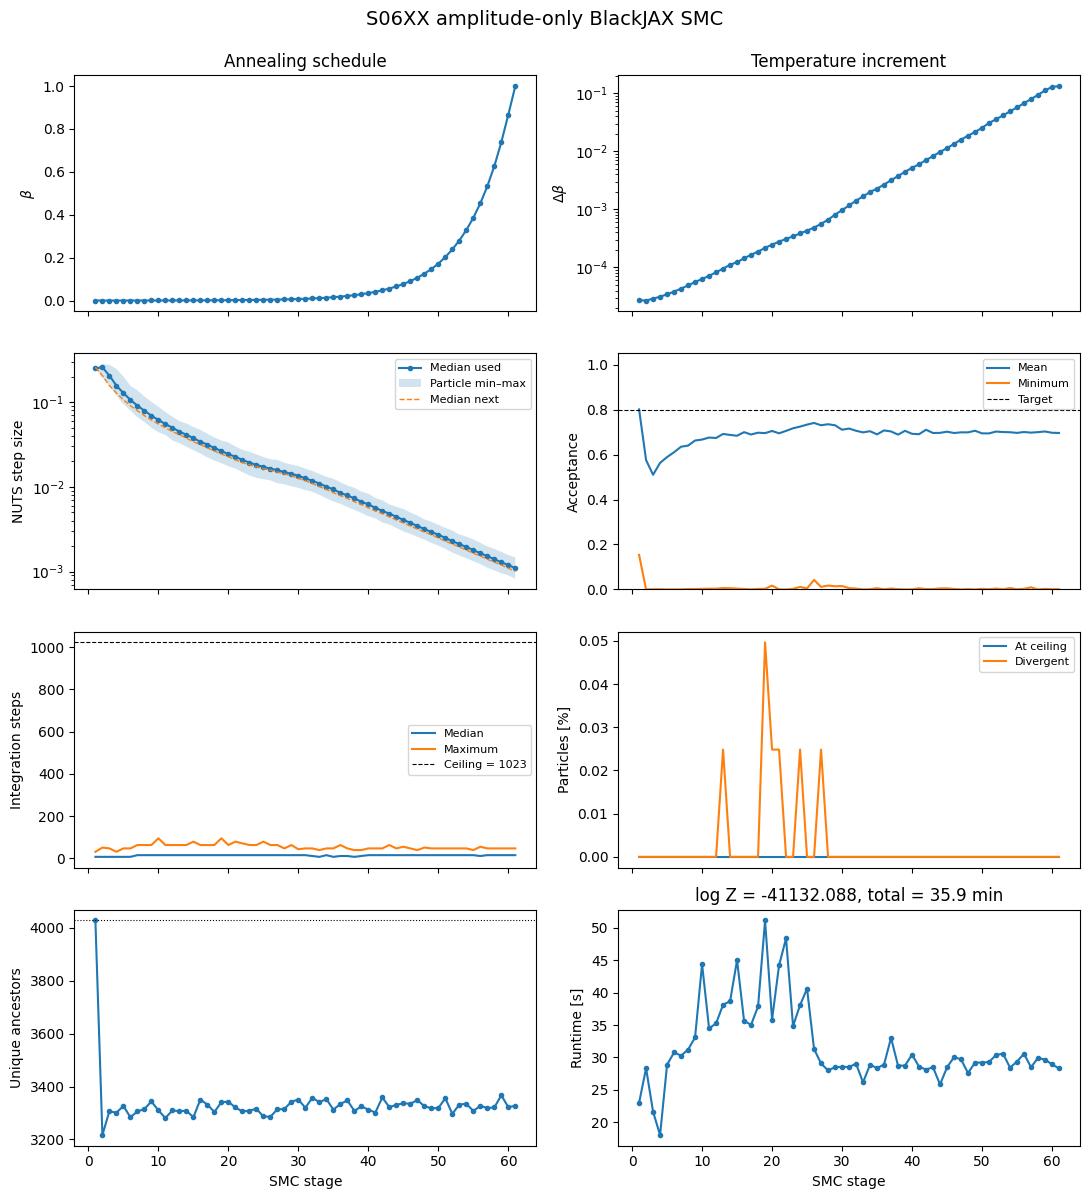

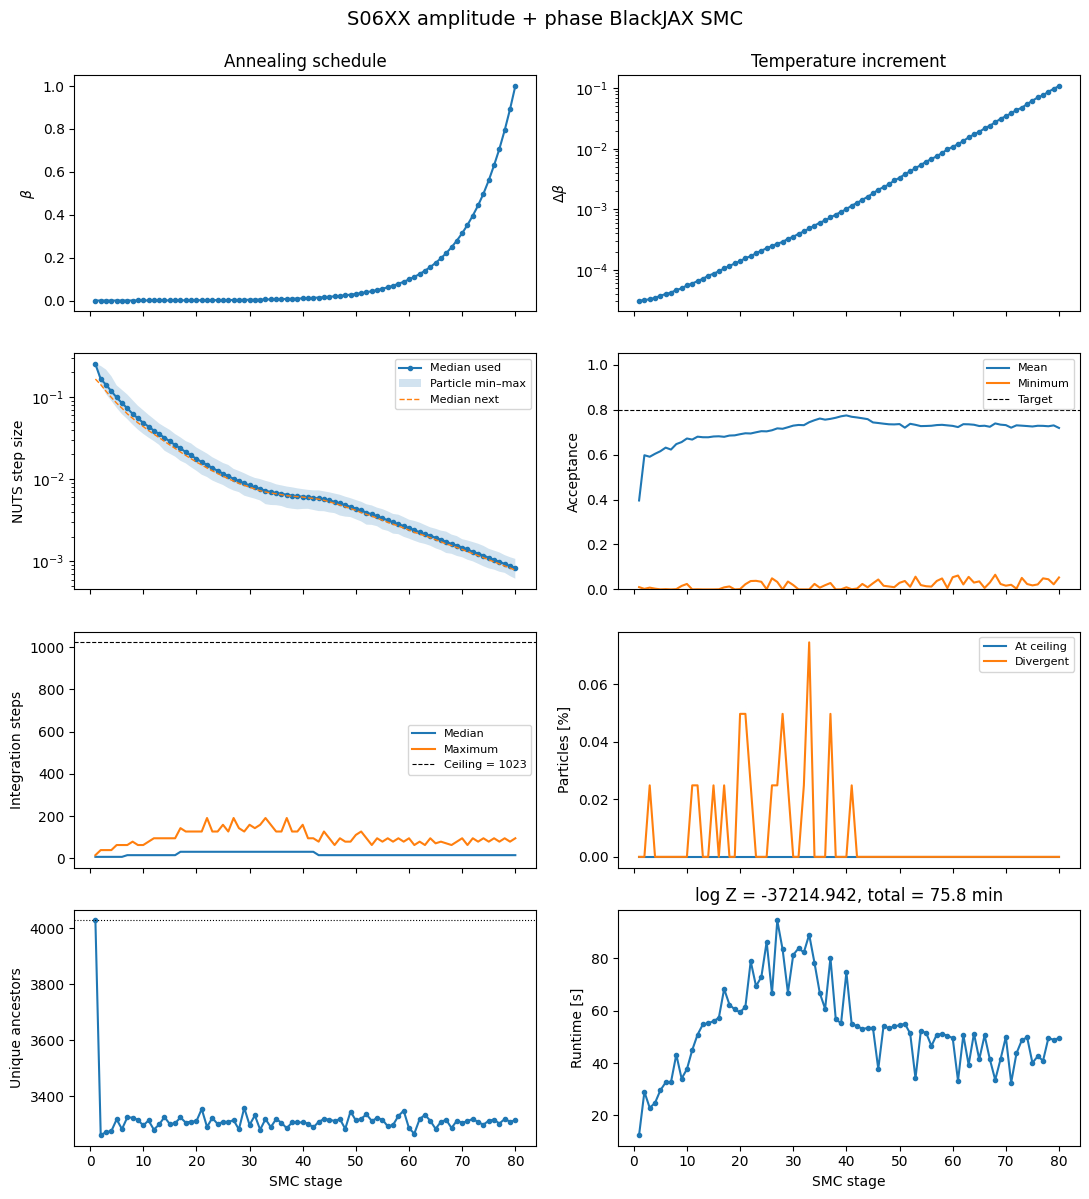

In [9]:
def plot_smc_diagnostics(fit, title):
    history = {
        key: np.asarray(value)
        for key, value in fit["stage_diagnostics"].items()
    }

    stage = np.asarray(history["stage"], dtype=int)
    max_doublings = int(fit["config"]["max_num_doublings"])
    max_steps = 2**max_doublings - 1

    fig, axes = plt.subplots(
        4,
        2,
        figsize=(11, 12),
        sharex=True,
    )
    axes = axes.ravel()

    axes[0].plot(stage, history["beta"], marker="o", ms=3)
    axes[0].set_ylabel(r"$\beta$")
    axes[0].set_title("Annealing schedule")

    axes[1].plot(stage, history["delta_beta"], marker="o", ms=3)
    axes[1].set_yscale("log")
    axes[1].set_ylabel(r"$\Delta\beta$")
    axes[1].set_title("Temperature increment")

    axes[2].plot(
        stage,
        history["step_used_median"],
        marker="o",
        ms=3,
        label="Median used",
    )
    axes[2].fill_between(
        stage,
        history["step_used_min"],
        history["step_used_max"],
        alpha=0.20,
        label="Particle min–max",
    )
    axes[2].plot(
        stage,
        history["step_next_median"],
        ls="--",
        lw=1,
        label="Median next",
    )
    axes[2].set_yscale("log")
    axes[2].set_ylabel("NUTS step size")
    axes[2].legend(fontsize=8)

    axes[3].plot(stage, history["mean_acceptance"], label="Mean")
    axes[3].plot(stage, history["min_acceptance"], label="Minimum")
    axes[3].axhline(
        float(fit["config"]["target_accept"]),
        color="black",
        ls="--",
        lw=0.8,
        label="Target",
    )
    axes[3].set_ylim(0, 1.05)
    axes[3].set_ylabel("Acceptance")
    axes[3].legend(fontsize=8)

    axes[4].plot(
        stage,
        history["median_integration_steps"],
        label="Median",
    )
    axes[4].plot(
        stage,
        history["max_integration_steps"],
        label="Maximum",
    )
    axes[4].axhline(
        max_steps,
        color="black",
        ls="--",
        lw=0.8,
        label=f"Ceiling = {max_steps}",
    )
    axes[4].set_ylabel("Integration steps")
    axes[4].legend(fontsize=8)

    axes[5].plot(
        stage,
        100 * history["ceiling_fraction"],
        label="At ceiling",
    )
    axes[5].plot(
        stage,
        100 * history["divergence_fraction"],
        label="Divergent",
    )
    axes[5].set_ylabel("Particles [%]")
    axes[5].legend(fontsize=8)

    axes[6].plot(
        stage,
        history["n_unique_ancestors"],
        marker=".",
    )
    axes[6].axhline(
        int(metadata["n_particles"]),
        color="black",
        ls=":",
        lw=0.8,
    )
    axes[6].set_ylabel("Unique ancestors")

    axes[7].plot(
        stage,
        history["runtime_seconds"],
        marker=".",
        label="Stage runtime",
    )
    axes[7].set_ylabel("Runtime [s]")
    axes[7].set_title(
        f"log Z = {float(fit['log_evidence']):.3f}, "
        f"total = {float(fit['runtime_seconds']) / 60:.1f} min"
    )

    for ax in axes[-2:]:
        ax.set_xlabel("SMC stage")

    fig.suptitle(title, fontsize=14, y=0.995)
    fig.tight_layout()
    plt.show()


plot_smc_diagnostics(
    amplitude_result,
    f"{tilepol} amplitude-only BlackJAX SMC",
)

plot_smc_diagnostics(
    complex_result,
    f"{tilepol} amplitude + phase BlackJAX SMC",
)

## 5. Final weighted posterior populations

BlackJAX returns a weighted particle approximation at the final target.  The
saved `weights` are therefore part of the posterior representation and are
used throughout the analysis below.

The raw particle count in a mode remains useful as a genealogy/discovery
diagnostic, but posterior mode mass is computed from the weights.


In [10]:
amplitude_particles = np.asarray(amplitude_result["particles"], dtype=float)
amplitude_log_prior = np.asarray(amplitude_result["log_prior"], dtype=float)
amplitude_log_likelihood = np.asarray(amplitude_result["log_likelihood"], dtype=float)
amplitude_log_density = amplitude_log_prior + amplitude_log_likelihood
amplitude_weights = np.asarray(amplitude_result["weights"], dtype=float)
amplitude_weights = amplitude_weights / amplitude_weights.sum()

amplitude_sites = amplitude_result["posterior_sites"]
amplitude_samples = np.asarray(
    amplitude_sites["dipole_gain_amplitude"],
    dtype=float,
)
amplitude_complex_gains = np.asarray(
    amplitude_sites["dipole_gain_complex"],
    dtype=np.complex64,
)

complex_particles = np.asarray(complex_result["particles"], dtype=float)
complex_log_prior = np.asarray(complex_result["log_prior"], dtype=float)
complex_log_likelihood = np.asarray(complex_result["log_likelihood"], dtype=float)
complex_log_density = complex_log_prior + complex_log_likelihood
complex_weights = np.asarray(complex_result["weights"], dtype=float)
complex_weights = complex_weights / complex_weights.sum()

complex_sites = complex_result["posterior_sites"]
complex_amplitudes = np.asarray(
    complex_sites["dipole_gain_amplitude"],
    dtype=float,
)
complex_phases_rad = np.asarray(
    complex_sites["dipole_gain_phase"],
    dtype=float,
)
complex_complex_gains = np.asarray(
    complex_sites["dipole_gain_complex"],
    dtype=np.complex64,
)

print("Final posterior populations")
print("---------------------------")
print(
    f"Amplitude: N={amplitude_particles.shape[0]}, "
    f"weight sum={amplitude_weights.sum():.8f}, "
    f"ESS={1 / np.sum(amplitude_weights**2):.1f}"
)
print(
    f"Complex:   N={complex_particles.shape[0]}, "
    f"weight sum={complex_weights.sum():.8f}, "
    f"ESS={1 / np.sum(complex_weights**2):.1f}"
)
print(
    "Amplitude-sum range:",
    complex_amplitudes.sum(axis=1).min(),
    "to",
    complex_amplitudes.sum(axis=1).max(),
)

Final posterior populations
---------------------------
Amplitude: N=4028, weight sum=1.00000000, ESS=3531.0
Complex:   N=4028, weight sum=1.00000000, ESS=3350.3
Amplitude-sum range: 15.999997735023499 to 16.000002145767212


# Part I — Amplitude-only posterior

The amplitude-only posterior is treated as a single posterior population.
Selected pairwise marginals are retained because they reveal targeted
covariances without the visual overload of a full 16-dimensional corner plot.


## 7. Amplitude posterior summary and pairwise marginals


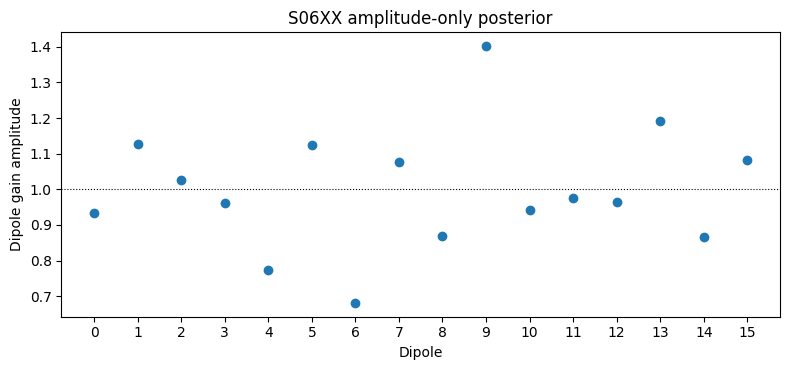

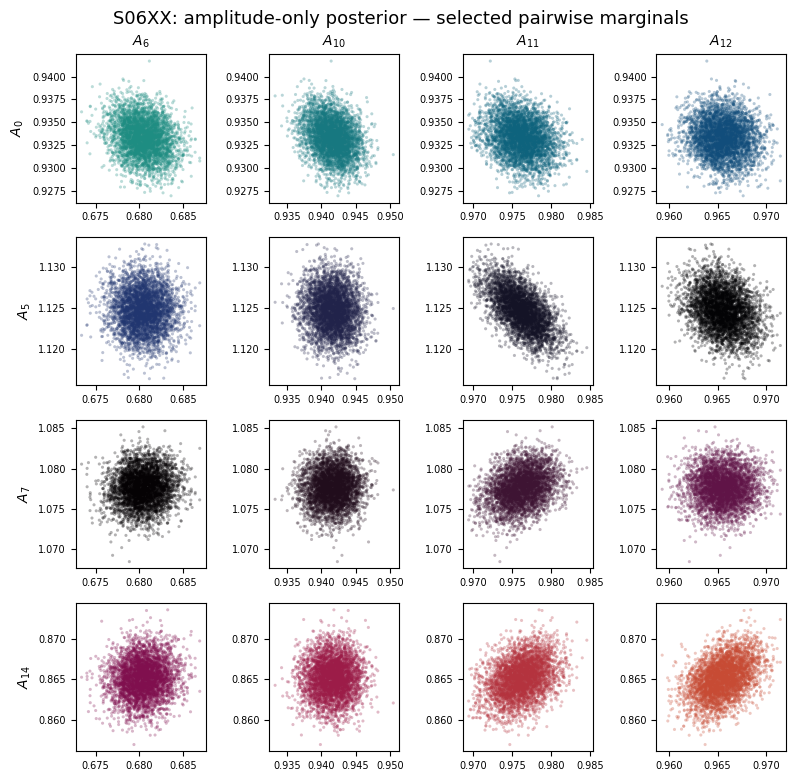

In [11]:
amplitude_parameter_labels = [
    rf"$A_{{{dipole}}}$"
    for dipole in range(N_DIPOLES)
]

q16, amp_median, q84 = weighted_quantile(
    amplitude_samples,
    [0.16, 0.50, 0.84],
    amplitude_weights,
)

fig, ax = plt.subplots(figsize=(8, 3.8))

ax.errorbar(
    dipoles,
    amp_median,
    yerr=np.vstack(
        [
            amp_median - q16,
            q84 - amp_median,
        ]
    ),
    fmt="o",
    capsize=2,
)

ax.axhline(1.0, color="black", ls=":", lw=0.8)
ax.set_xlabel("Dipole")
ax.set_ylabel("Dipole gain amplitude")
ax.set_xticks(dipoles)
ax.set_title(f"{tilepol} amplitude-only posterior")

fig.tight_layout()
plt.savefig(
    f"{OUTDIR_PATH}/{tilepol}_2_Amp_Posterior.pdf"
)
plt.show()

plot_cross_pairwise_marginals(
    amplitude_samples,
    amplitude_parameter_labels,
    group_size=4,
    seed=69,
    title=f"{tilepol}: amplitude-only posterior — selected pairwise marginals",
    outpath=OUTDIR_PATH / f"{tilepol}_3_Amplitude_Pairwise_Marginals.pdf",
)

### Why there is no analogous amplitude-only symmetry branch

As a direct numerical check, transform a representative amplitude-only gain
vector using the same conjugate-rotation map. If the resulting gains acquire
non-zero phases, the symmetry partner lies outside the amplitude-only
parameter space even though it is allowed by the complex model.


Amplitude-only symmetry-partner check
-------------------------------------
max transformed |phase| [deg]: 1.524
transformed amplitude sum: 16.00004578
S(reference), S(partner): -1.420309e-06, +1.420307e-06


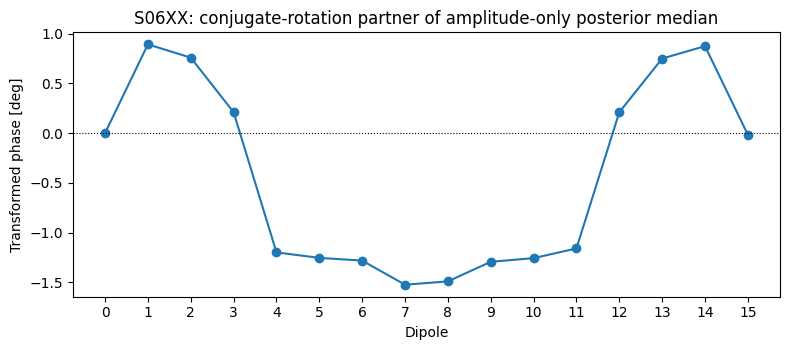

In [12]:
amplitude_reference = np.asarray(
    weighted_quantile(
        amplitude_samples,
        [0.5],
        amplitude_weights,
    )[0],
    dtype=np.complex64,
)

amplitude_partner = conjugate_rotate_gains(amplitude_reference)

print("Amplitude-only symmetry-partner check")
print("-------------------------------------")
print(
    "max transformed |phase| [deg]:",
    f"{np.max(np.abs(np.rad2deg(np.angle(amplitude_partner)))):.3f}",
)
print(
    "transformed amplitude sum:",
    f"{np.abs(amplitude_partner).sum():.8f}",
)
print(
    "S(reference), S(partner):",
    f"{symmetry_statistic_single(amplitude_reference):+.6e},",
    f"{symmetry_statistic_single(amplitude_partner):+.6e}",
)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(
    dipoles,
    np.rad2deg(np.angle(amplitude_partner)),
    "o-",
)
ax.axhline(0.0, color="black", ls=":", lw=0.8)
ax.set_xlabel("Dipole")
ax.set_ylabel("Transformed phase [deg]")
ax.set_xticks(dipoles)
ax.set_title(
    f"{tilepol}: conjugate-rotation partner of amplitude-only posterior median"
)
fig.tight_layout()
plt.show()

# Part II — Complex posterior and symmetry branches

The complex posterior is interpreted using the analytic symmetry from the
outset. The raw posterior is first inspected with selected pairwise marginals,
then every particle is assigned deterministically to \(S>0\) or \(S<0\).


## 8. Raw complex posterior and pairwise marginals


In [13]:
relative_phases_rad = complex_phases_rad[:, 1:]

phase_circular_mean_rad = weighted_circular_mean(
    relative_phases_rad,
    complex_weights,
)

phase_offsets_rad = np.angle(
    np.exp(
        1j
        * (
            relative_phases_rad
            - phase_circular_mean_rad[None, :]
        )
    )
)

phase_offsets_deg = np.rad2deg(phase_offsets_rad)

complex_amplitude_parameter_labels = [
    rf"$A_{{{dipole}}}$" for dipole in range(N_DIPOLES)
]
complex_phase_parameter_labels = [
    rf"$\phi_{{{dipole}}}$" for dipole in range(1, N_DIPOLES)
]

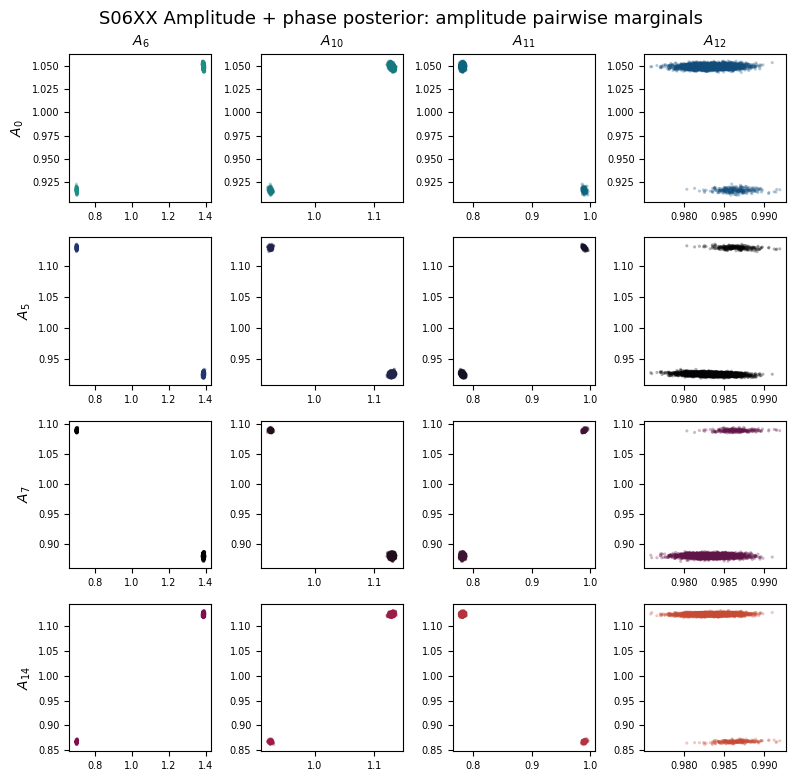

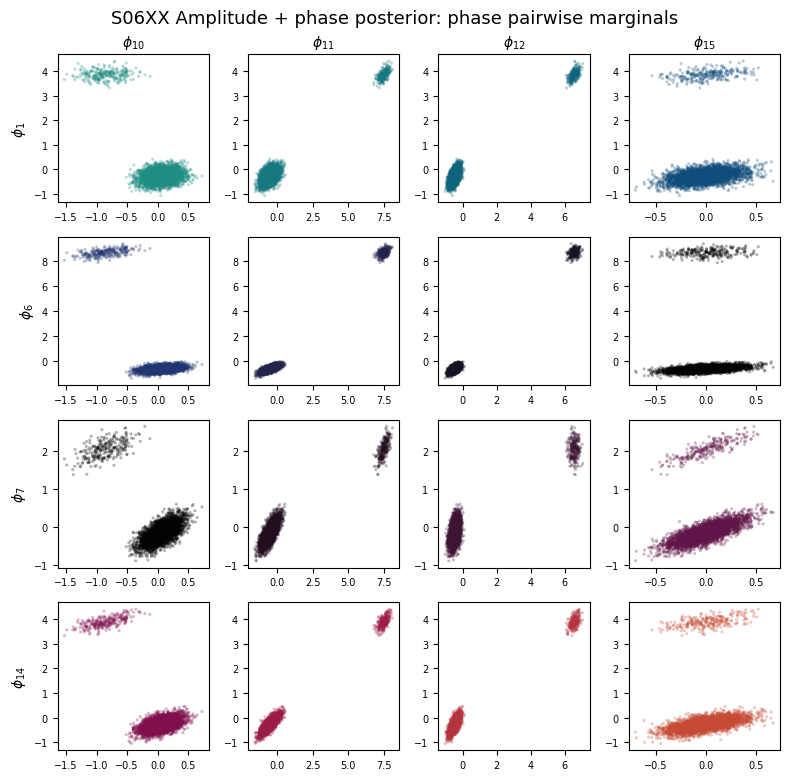

In [14]:
plot_cross_pairwise_marginals(
    complex_amplitudes,
    complex_amplitude_parameter_labels,
    group_size=4,
    seed=69,
    title=f"{tilepol} Amplitude + phase posterior: amplitude pairwise marginals",
    outpath=f"{OUTDIR_PATH}/{tilepol}_4_1_Amp_Phase_Random_Amp_Pairwise_Marginals.pdf"

)

plot_cross_pairwise_marginals(
    phase_offsets_deg,
    complex_phase_parameter_labels,
    group_size=4,
    seed=69,
    title=f"{tilepol} Amplitude + phase posterior: phase pairwise marginals",
    outpath=f"{OUTDIR_PATH}/{tilepol}_4_2_Amp_Phase_Random_Phase_Pairwise_Marginals.pdf"
)

## 9. Deterministic \(S(g)\) branch classification


Complex posterior symmetry branches
-----------------------------------
S > 0: 3764/4028 particles; posterior mass=93.334%
S < 0:  264/4028 particles; posterior mass=6.666%
closest |S|: 1.186552e-06


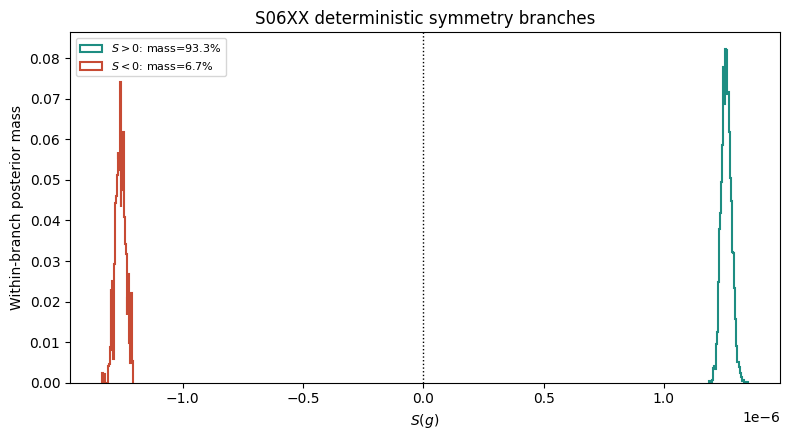

In [15]:
symmetry_statistic = symmetry_statistic_many(complex_complex_gains)

positive = symmetry_statistic > 0
negative = symmetry_statistic < 0

if np.any(symmetry_statistic == 0):
    raise ValueError("At least one particle lies exactly on S=0.")

complex_branch_labels = np.where(positive, 0, 1)
N_COMPLEX_BRANCHES = 2

branch_masks = {
    +1: positive,
    -1: negative,
}

print("Complex posterior symmetry branches")
print("-----------------------------------")
for sign, mask in branch_masks.items():
    relation = ">" if sign > 0 else "<"
    print(
        f"S {relation} 0: "
        f"{mask.sum():4d}/{mask.size} particles; "
        f"posterior mass={complex_weights[mask].sum():.3%}"
    )

print(
    f"closest |S|: {np.min(np.abs(symmetry_statistic)):.6e}"
)

fig, ax = plt.subplots(figsize=(8, 4.5))

i=0
for sign, mask in branch_masks.items():
    if not np.any(mask):
        continue

    relation = ">" if sign > 0 else "<"

    ax.hist(
        symmetry_statistic[mask],
        bins=40,
        weights=normalize_weights(complex_weights[mask]),
        histtype="step",
        linewidth=1.5,
        label=(
            rf"$S {relation} 0$: "
            f"mass={complex_weights[mask].sum():.1%}"
        ),
        color=MODE_COLORS[i]
    )
    i+=1

ax.axvline(0.0, color="black", ls=":", lw=1.0)
ax.set_xlabel(r"$S(g)$")
ax.set_ylabel("Within-branch posterior mass")
ax.set_title(f"{tilepol} deterministic symmetry branches")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 10. Branch-conditioned dipole-gain solutions


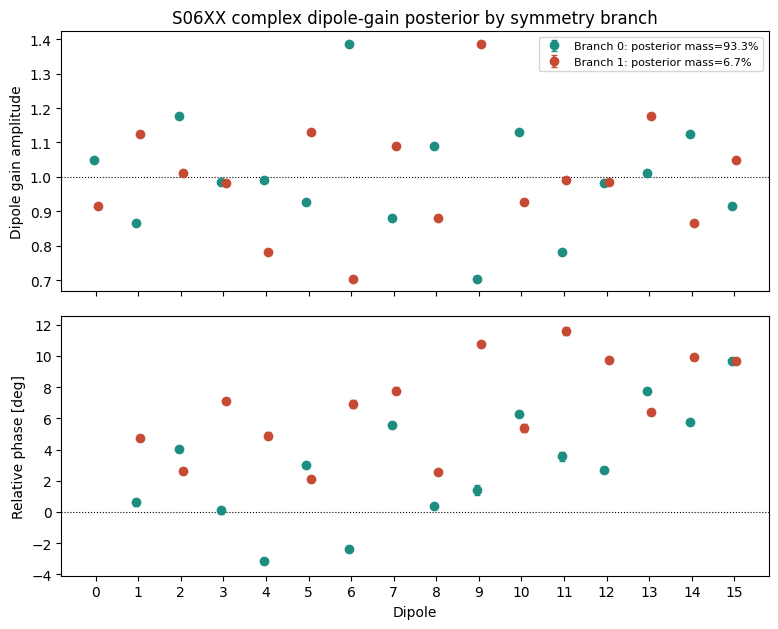

In [16]:
complex_branch_parameter_samples = []
complex_branch_phase_mean_deg = []
complex_branch_phase_low_error_deg = []
complex_branch_phase_high_error_deg = []

fig, (ax_amp, ax_phase) = plt.subplots(
    2,
    1,
    figsize=(8, 6.4),
    sharex=True,
)

for branch_index in range(N_COMPLEX_BRANCHES):
    mask = complex_branch_labels == branch_index
    branch_weights = normalize_weights(complex_weights[mask])
    branch_amplitudes = complex_amplitudes[mask]
    branch_phases_rad = relative_phases_rad[mask]

    amp_q16, amp_median, amp_q84 = weighted_quantile(
        branch_amplitudes,
        [0.16, 0.50, 0.84],
        branch_weights,
    )

    phase_mean_rad = weighted_circular_mean(
        branch_phases_rad,
        branch_weights,
    )
    branch_phase_offsets_deg = np.rad2deg(
        np.angle(
            np.exp(
                1j
                * (
                    branch_phases_rad
                    - phase_mean_rad[None, :]
                )
            )
        )
    )

    phase_q16, _, phase_q84 = weighted_quantile(
        branch_phase_offsets_deg,
        [0.16, 0.50, 0.84],
        branch_weights,
    )
    phase_low_error_deg = np.maximum(0.0, -phase_q16)
    phase_high_error_deg = np.maximum(0.0, phase_q84)

    complex_branch_parameter_samples.append(
        np.column_stack(
            [
                branch_amplitudes,
                branch_phase_offsets_deg,
            ]
        )
    )
    complex_branch_phase_mean_deg.append(
        np.rad2deg(phase_mean_rad)
    )
    complex_branch_phase_low_error_deg.append(
        phase_low_error_deg
    )
    complex_branch_phase_high_error_deg.append(
        phase_high_error_deg
    )

    x = dipoles + 0.10 * (
        branch_index
        - 0.5 * (N_COMPLEX_BRANCHES - 1)
    )

    ax_amp.errorbar(
        x,
        amp_median,
        yerr=np.vstack(
            [
                amp_median - amp_q16,
                amp_q84 - amp_median,
            ]
        ),
        fmt="o",
        capsize=2,
        color=MODE_COLORS[branch_index],
        label=(
            f"Branch {branch_index}: "
            f"posterior mass={complex_weights[mask].sum():.1%}"
        ),
    )

    ax_phase.errorbar(
        x[1:],
        np.rad2deg(phase_mean_rad),
        yerr=np.vstack(
            [
                phase_low_error_deg,
                phase_high_error_deg,
            ]
        ),
        fmt="o",
        capsize=2,
        color=MODE_COLORS[branch_index],
    )

ax_amp.axhline(1.0, color="black", ls=":", lw=0.8)
ax_phase.axhline(0.0, color="black", ls=":", lw=0.8)
ax_amp.set_ylabel("Dipole gain amplitude")
ax_phase.set_ylabel("Relative phase [deg]")
ax_phase.set_xlabel("Dipole")
ax_phase.set_xticks(dipoles)
ax_amp.legend(fontsize=8)
ax_amp.set_title(
    f"{tilepol} complex dipole-gain posterior by symmetry branch"
)

fig.tight_layout()
plt.savefig(
    f"{OUTDIR_PATH}/{tilepol}_5_Complex_Posterior.pdf"
)
plt.show()

### Paired forward-model symmetry control

Before interpreting any difference between the *posterior populations* of the
two branches, verify that the analytic transformation itself preserves the
power beam to numerical precision for representative particles. This separates
an exact model-symmetry control from branch-conditioned posterior differences.


In [17]:
rng = np.random.default_rng(69)
candidate_indices = np.flatnonzero(positive)
test_indices = rng.choice(
    candidate_indices,
    size=min(16, candidate_indices.size),
    replace=False,
)

paired_differences = []

for index in test_indices:
    g = complex_complex_gains[index]
    gt = conjugate_rotate_gains(g)

    b = np.asarray(
        predict_beam_db(jnp.asarray(g, dtype=jnp.complex64)),
        dtype=float,
    )
    bt = np.asarray(
        predict_beam_db(jnp.asarray(gt, dtype=jnp.complex64)),
        dtype=float,
    )

    paired_differences.append(bt - b)

paired_differences = np.asarray(paired_differences)

print("Paired conjugate-rotation beam control")
print("--------------------------------------")
print(
    "RMS difference [dB]:",
    f"{np.sqrt(np.mean(paired_differences**2)):.6e}",
)
print(
    "max |difference| [dB]:",
    f"{np.max(np.abs(paired_differences)):.6e}",
)

Paired conjugate-rotation beam control
--------------------------------------
RMS difference [dB]: 3.987601e-06
max |difference| [dB]: 4.959106e-05


## 11. Symmetry-related local modes and branch-mass interpretation

The complex posterior contains two branches related by the conjugate-rotation
symmetry derived above. The weighted SMC branch masses are the primary
posterior result, while a local Laplace approximation provides an independent
check on the relative integrated mass near the two modes.

The analysis below separates three questions:

1. do independently refined local modes reproduce the two SMC branches?
2. does the exact conjugate transformation preserve the power-beam likelihood?
3. if so, what produces the unequal posterior mass of the two branches?

The exact transformed pair is used to diagnose the origin of the asymmetry,
while the independently optimized MAPs are used for the local Laplace
approximation.


In [18]:
from scipy.optimize import minimize
from scipy.special import i0e

branch_weight_masses = np.array(
    [
        complex_weights[positive].sum(),
        complex_weights[negative].sum(),
    ]
)

dominant_branch = int(np.argmax(branch_weight_masses))
dominant_mask = positive if dominant_branch == 0 else negative
dominant_indices = np.flatnonzero(dominant_mask)

source_index = dominant_indices[
    np.argmax(complex_log_density[dominant_mask])
]

source_gains = np.asarray(
    complex_complex_gains[source_index],
    dtype=np.complex64,
)

partner_gains = conjugate_rotate_gains(source_gains)

print("Symmetry-seeded local branches")
print("---------------------------")
print(f"Dominant SMC branch:       {dominant_branch}")
print(f"Source particle:         {source_index}")
print(f"Source S(g):             {symmetry_statistic_single(source_gains):+.6e}")
print(f"Partner S(g):            {symmetry_statistic_single(partner_gains):+.6e}")
print(f"Source amplitude sum:    {np.abs(source_gains).sum():.8f}")
print(f"Partner amplitude sum:   {np.abs(partner_gains).sum():.8f}")
print(f"Partner phi_0 [deg]:     {np.rad2deg(np.angle(partner_gains[0])):+.3e}")


Symmetry-seeded local branches
---------------------------
Dominant SMC branch:       0
Source particle:         2790
Source S(g):             +1.255606e-06
Partner S(g):            -1.255605e-06
Source amplitude sum:    16.00000000
Partner amplitude sum:   16.00049973
Partner phi_0 [deg]:     +7.854e-07


### Local target and MAP refinement

The optimizer and Hessian must use exactly the same posterior target as the SMC
analysis. We therefore reconstruct the soft-Laplace likelihood, Dirichlet
amplitude prior, zero-centred von Mises phase prior, and additive-log-ratio
(ALR) Jacobian explicitly in unconstrained coordinates.


In [19]:
# -------------------------------------------------------------------------
# Explicit ALR + relative-phase target used by the SMC run.
# -------------------------------------------------------------------------

DIRICHLET_ALPHA = float(metadata["dirichlet_alpha"])
PHASE_PRIOR_STD_RAD = np.deg2rad(float(metadata["phase_prior_std_deg"]))
PHASE_KAPPA = 1.0 / PHASE_PRIOR_STD_RAD**2

observed_db_jax = jnp.asarray(observed_db, dtype=jnp.float32)
observed_sigma_db_jax = jnp.asarray(observed_sigma_db, dtype=jnp.float32)

dirichlet_alpha_jax = jnp.full(
    N_DIPOLES,
    DIRICHLET_ALPHA,
    dtype=jnp.float32,
)


def gains_to_unconstrained(gains):
    """Physical gains -> ALR amplitudes + relative phases."""
    gains = np.asarray(gains, dtype=np.complex64)
    amplitude = np.abs(gains)
    fraction = amplitude / amplitude.sum()

    amp_coordinates = np.log(
        fraction[:-1] / fraction[-1]
    )
    phase_coordinates = np.angle(
        gains[1:] / gains[0]
    )

    return np.concatenate(
        [amp_coordinates, phase_coordinates]
    ).astype(np.float32)


def unconstrained_to_gains(z):
    """ALR amplitudes + relative phases -> simplex-constrained gains."""
    z = jnp.asarray(z)

    amp_coordinates = z[: N_DIPOLES - 1]
    relative_phase = z[N_DIPOLES - 1 :]

    logits = jnp.concatenate(
        [amp_coordinates, jnp.zeros(1, dtype=z.dtype)]
    )
    fraction = jax.nn.softmax(logits)
    amplitude = N_DIPOLES * fraction

    phase = jnp.concatenate(
        [jnp.zeros(1, dtype=z.dtype), relative_phase]
    )
    gains = amplitude * jnp.exp(1j * phase)

    return fraction, gains.astype(jnp.complex64)


def soft_laplace_log_likelihood_from_gains(gains):
    """Soft-Laplace log likelihood evaluated directly in gain space."""
    gains = jnp.asarray(gains, dtype=jnp.complex64)
    model_db = predict_beam_db(gains)

    residual = (
        observed_db_jax - model_db
    ) / observed_sigma_db_jax

    scaled_residual = 0.5 * jnp.pi * residual
    log_cosh = (
        jnp.logaddexp(scaled_residual, -scaled_residual)
        - jnp.log(2.0)
    )

    return -jnp.sum(
        log_cosh + jnp.log(2.0 * observed_sigma_db_jax)
    )


def posterior_components(z):
    """Likelihood, priors, Jacobian, and posterior in one canonical helper."""
    z = jnp.asarray(z)
    fraction, gains = unconstrained_to_gains(z)

    log_likelihood = soft_laplace_log_likelihood_from_gains(
        gains
    )

    log_prior_amp = (
        jax.scipy.special.gammaln(
            jnp.sum(dirichlet_alpha_jax)
        )
        - jnp.sum(
            jax.scipy.special.gammaln(
                dirichlet_alpha_jax
            )
        )
        + jnp.sum(
            (dirichlet_alpha_jax - 1.0)
            * jnp.log(fraction)
        )
    )

    relative_phase = z[N_DIPOLES - 1 :]
    log_i0 = (
        jnp.log(
            jax.scipy.special.i0e(PHASE_KAPPA)
        )
        + PHASE_KAPPA
    )

    log_prior_phase = jnp.sum(
        PHASE_KAPPA * jnp.cos(relative_phase)
        - jnp.log(2.0 * jnp.pi)
        - log_i0
    )

    log_prior_physical = (
        log_prior_amp + log_prior_phase
    )
    log_jacobian = jnp.sum(
        jnp.log(fraction)
    )

    log_posterior_physical = (
        log_likelihood + log_prior_physical
    )
    log_posterior_transformed = (
        log_posterior_physical + log_jacobian
    )

    return {
        "log_likelihood": log_likelihood,
        "log_prior_amp": log_prior_amp,
        "log_prior_phase": log_prior_phase,
        "log_prior_physical": log_prior_physical,
        "log_jacobian": log_jacobian,
        "log_posterior_physical": log_posterior_physical,
        "log_posterior_transformed": log_posterior_transformed,
    }


def physical_log_posterior(z):
    return posterior_components(z)["log_posterior_physical"]


def transformed_log_posterior(z):
    return posterior_components(z)["log_posterior_transformed"]


negative_transformed_log_posterior = jax.jit(
    lambda z: -transformed_log_posterior(z)
)

negative_value_and_grad = jax.jit(
    jax.value_and_grad(
        lambda z: -transformed_log_posterior(z)
    )
)


def scipy_objective(z):
    value, gradient = negative_value_and_grad(
        jnp.asarray(z)
    )
    return float(value), np.asarray(
        gradient,
        dtype=np.float32,
    )


source_z0 = gains_to_unconstrained(source_gains)
partner_z0 = gains_to_unconstrained(partner_gains)

print("Target at initial symmetry-related seeds")
print("----------------------------------------")
for name, z0 in (
    ("source", source_z0),
    ("partner", partner_z0),
):
    components = posterior_components(jnp.asarray(z0))
    print(
        f"{name:8s}: "
        f"logL={float(components['log_likelihood']):.3f}, "
        f"physical logP={float(components['log_posterior_physical']):.3f}, "
        f"transformed logP={float(components['log_posterior_transformed']):.3f}"
    )


Target at initial symmetry-related seeds
----------------------------------------
source  : logL=-37068.168, physical logP=-37012.941, transformed logP=-37057.504
partner : logL=-37068.168, physical logP=-37015.527, transformed logP=-37060.090


In [20]:
# -------------------------------------------------------------------------
# Independently refine the two symmetry-related seeds.
#
# map_results and map_gains are the authoritative local-mode objects used
# everywhere downstream.
# -------------------------------------------------------------------------

MAP_MAXITER = 2_000
MAP_FTOL = 1e-10
MAP_GTOL = 1e-6


def refine_local_mode(z0):
    return minimize(
        scipy_objective,
        np.asarray(z0, dtype=np.float32),
        method="L-BFGS-B",
        jac=True,
        options={
            "maxiter": MAP_MAXITER,
            "ftol": MAP_FTOL,
            "gtol": MAP_GTOL,
            "maxls": 50,
        },
    )


map_results = {
    "source": refine_local_mode(source_z0),
    "partner": refine_local_mode(partner_z0),
}

map_gains = {}

print("Local MAP refinement")
print("--------------------")

for name, result_map in map_results.items():
    z_map = jnp.asarray(result_map.x)
    _, gains = unconstrained_to_gains(z_map)
    gains = np.asarray(gains)

    map_gains[name] = gains
    components = posterior_components(z_map)

    print(f"{name.capitalize()} mode")
    print(f"  success:             {result_map.success}")
    print(f"  message:             {result_map.message}")
    print(f"  iterations:          {result_map.nit}")
    print(
        f"  transformed logP:    "
        f"{float(components['log_posterior_transformed']):.3f}"
    )
    print(
        f"  physical logP:       "
        f"{float(components['log_posterior_physical']):.3f}"
    )
    print(
        f"  S(g):                "
        f"{symmetry_statistic_single(gains):+.6e}"
    )
    print(
        f"  amplitude sum:       "
        f"{np.abs(gains).sum():.8f}"
    )
    print()

if np.sign(
    symmetry_statistic_single(map_gains["source"])
) == np.sign(
    symmetry_statistic_single(map_gains["partner"])
):
    print(
        "WARNING: both optimizations finished "
        "on the same S(g) branch."
    )


Local MAP refinement
--------------------
Source mode
  success:             True
  message:             CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  iterations:          24
  transformed logP:    -37052.301
  physical logP:       -37007.738
  S(g):                +1.258538e-06
  amplitude sum:       16.00000000

Partner mode
  success:             True
  message:             CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  iterations:          25
  transformed logP:    -37054.828
  physical logP:       -37010.266
  S(g):                -1.258744e-06
  amplitude sum:       16.00000000



### Origin of the branch-mass asymmetry

We first compare the two independently optimized MAPs. This decomposition is
useful for the local Laplace calculation, but it does not by itself identify
the cause of the asymmetry because the two MAPs can move independently within
their respective posterior neighbourhoods.


In [21]:
# -------------------------------------------------------------------------
# MAP posterior decomposition.
# Positive differences favour the source / dominant branch.
# -------------------------------------------------------------------------

map_components = {
    name: {
        key: float(value)
        for key, value in posterior_components(
            jnp.asarray(result_map.x)
        ).items()
    }
    for name, result_map in map_results.items()
}

delta_map = {
    key: (
        map_components["source"][key]
        - map_components["partner"][key]
    )
    for key in map_components["source"]
}

print("MAP posterior decomposition: source - partner")
print("=============================================")
print(
    f"Delta log likelihood:        "
    f"{delta_map['log_likelihood']:+.6f}"
)
print(
    f"Delta log amplitude prior:   "
    f"{delta_map['log_prior_amp']:+.6f}"
)
print(
    f"Delta log phase prior:       "
    f"{delta_map['log_prior_phase']:+.6f}"
)
print(
    f"Delta log ALR Jacobian:      "
    f"{delta_map['log_jacobian']:+.6f}"
)
print("---------------------------------------------")
print(
    f"Delta physical logP:         "
    f"{delta_map['log_posterior_physical']:+.6f}"
)
print(
    f"Delta transformed logP:      "
    f"{delta_map['log_posterior_transformed']:+.6f}"
)


MAP posterior decomposition: source - partner
Delta log likelihood:        +0.000000
Delta log amplitude prior:   -0.000214
Delta log phase prior:       +2.528107
Delta log ALR Jacobian:      -0.000038
---------------------------------------------
Delta physical logP:         +2.527344
Delta transformed logP:      +2.527344


### Exact-pair symmetry and prior control

The decisive test uses the source MAP and its **exact conjugate-rotation
partner**, before independently optimizing the second mode. If the
transformation is a true power-beam symmetry, the two predictions and
likelihoods should agree to numerical precision.

Any posterior preference already present for this exact pair must therefore
come from the prior (or coordinate measure), rather than from a data-driven
distinction between their beams.


In [22]:
# -------------------------------------------------------------------------
# Exact conjugate-pair control.
# -------------------------------------------------------------------------

def relative_phases_from_gains(gains):
    """Phases relative to dipole 0, wrapped to [-pi, pi)."""
    gains = np.asarray(gains)
    phase = np.angle(gains)
    phase = phase - phase[0]
    return (
        phase + np.pi
    ) % (2.0 * np.pi) - np.pi


def von_mises_phase_log_prior_from_gains(gains):
    """Physical phase-prior density for a gain vector."""
    relative_phase = relative_phases_from_gains(
        gains
    )[1:]

    log_i0 = (
        np.log(
            float(
                jax.scipy.special.i0e(
                    PHASE_KAPPA
                )
            )
        )
        + PHASE_KAPPA
    )

    per_dipole = (
        PHASE_KAPPA * np.cos(relative_phase)
        - np.log(2.0 * np.pi)
        - log_i0
    )

    return float(np.sum(per_dipole)), per_dipole


g_source_map = np.asarray(
    map_gains["source"],
    dtype=np.complex64,
)
g_symmetry_partner = conjugate_rotate_gains(
    g_source_map
)

# The exact transformed point is slightly off the amplitude simplex.
# Project it back only as a control.
z_projected_partner = gains_to_unconstrained(
    g_symmetry_partner
)
_, g_projected_partner = unconstrained_to_gains(
    jnp.asarray(z_projected_partner)
)
g_projected_partner = np.asarray(
    g_projected_partner
)

beam_source = np.asarray(
    predict_beam_db(
        jnp.asarray(g_source_map)
    ),
    dtype=float,
)
beam_symmetry_partner = np.asarray(
    predict_beam_db(
        jnp.asarray(g_symmetry_partner)
    ),
    dtype=float,
)
beam_difference_exact = (
    beam_source - beam_symmetry_partner
)

logL_source = float(
    soft_laplace_log_likelihood_from_gains(
        g_source_map
    )
)
logL_symmetry_partner = float(
    soft_laplace_log_likelihood_from_gains(
        g_symmetry_partner
    )
)
logL_projected_partner = float(
    soft_laplace_log_likelihood_from_gains(
        g_projected_partner
    )
)

phase_prior_source, phase_prior_per_dipole_source = (
    von_mises_phase_log_prior_from_gains(
        g_source_map
    )
)
phase_prior_symmetry_partner, phase_prior_per_dipole_partner = (
    von_mises_phase_log_prior_from_gains(
        g_symmetry_partner
    )
)

delta_logL_exact = (
    logL_source - logL_symmetry_partner
)
delta_log_phase_prior_exact = (
    phase_prior_source - phase_prior_symmetry_partner
)

prior_source_fraction = (
    1.0
    / (
        1.0
        + np.exp(-delta_log_phase_prior_exact)
    )
)
smc_source_fraction = (
    branch_weight_masses[dominant_branch]
)

print("Exact conjugate-pair control")
print("============================")
print()
print("Forward beam / likelihood")
print("-------------------------")
print(
    f"RMS beam difference:          "
    f"{np.sqrt(np.mean(beam_difference_exact**2)):.6e} dB"
)
print(
    f"max |beam difference|:        "
    f"{np.max(np.abs(beam_difference_exact)):.6e} dB"
)
print(
    f"Delta logL, source - exact:   "
    f"{delta_logL_exact:+.6f}"
)
print(
    f"Delta logL after simplex projection: "
    f"{logL_source - logL_projected_partner:+.6f}"
)
print()
print("Phase-prior asymmetry")
print("---------------------")
print(
    f"RMS |phase|, source:          "
    f"{np.sqrt(np.mean(np.rad2deg(relative_phases_from_gains(g_source_map)[1:])**2)):.3f} deg"
)
print(
    f"RMS |phase|, exact partner:   "
    f"{np.sqrt(np.mean(np.rad2deg(relative_phases_from_gains(g_symmetry_partner)[1:])**2)):.3f} deg"
)
print(
    f"Delta log phase prior:        "
    f"{delta_log_phase_prior_exact:+.6f}"
)
print(
    f"Prior-only two-mode fraction: "
    f"{prior_source_fraction:.2%} / "
    f"{1.0 - prior_source_fraction:.2%}"
)
print(
    f"Weighted SMC branch fraction: "
    f"{smc_source_fraction:.2%} / "
    f"{1.0 - smc_source_fraction:.2%}"
)
print()
print("Geometry sanity checks")
print("----------------------")
print(
    f"Source amplitude sum:         "
    f"{np.abs(g_source_map).sum():.8f}"
)
print(
    f"Exact partner amplitude sum:  "
    f"{np.abs(g_symmetry_partner).sum():.8f}"
)
print(
    f"Projected amplitude sum:      "
    f"{np.abs(g_projected_partner).sum():.8f}"
)

delta_phase_prior_per_dipole = (
    phase_prior_per_dipole_source
    - phase_prior_per_dipole_partner
)


Exact conjugate-pair control

Forward beam / likelihood
-------------------------
RMS beam difference:          3.707629e-06 dB
max |beam difference|:        3.433228e-05 dB
Delta logL, source - exact:   +0.003906
Delta logL after simplex projection: +0.003906

Phase-prior asymmetry
---------------------
RMS |phase|, source:          4.640 deg
RMS |phase|, exact partner:   7.448 deg
Delta log phase prior:        +2.538991
Prior-only two-mode fraction: 92.68% / 7.32%
Weighted SMC branch fraction: 93.33% / 6.67%

Geometry sanity checks
----------------------
Source amplitude sum:         16.00000000
Exact partner amplitude sum:  16.00051689
Projected amplitude sum:      16.00000000


### Local Laplace branch-mass approximation

We now evaluate the Hessian of the transformed negative log posterior at the
two independently optimized MAPs. This is a **Gaussian local approximation to
the soft-Laplace posterior**, not a Gaussian likelihood model. Positive
definiteness is checked before interpreting the local mode masses.


In [23]:
# -------------------------------------------------------------------------
# Hessians and Laplace mode masses.
# -------------------------------------------------------------------------

hessian_fn = jax.jit(
    jax.hessian(lambda z: -transformed_log_posterior(z))
)

laplace_results = {}
D_LATENT = 2 * (N_DIPOLES - 1)

for name, result_map in map_results.items():
    z_map = jnp.asarray(result_map.x)
    hessian = np.asarray(hessian_fn(z_map), dtype=np.float64)
    hessian = 0.5 * (hessian + hessian.T)

    eigenvalues = np.linalg.eigvalsh(hessian)
    sign, logdet = np.linalg.slogdet(hessian)
    transformed_logp = float(transformed_log_posterior(z_map))
    physical_logp = float(physical_log_posterior(z_map))

    valid = (
        sign > 0
        and np.all(np.isfinite(eigenvalues))
        and eigenvalues.min() > 0.0
    )

    log_mass = (
        transformed_logp
        + 0.5 * D_LATENT * np.log(2.0 * np.pi)
        - 0.5 * logdet
        if valid
        else np.nan
    )

    laplace_results[name] = {
        "hessian": hessian,
        "eigenvalues": eigenvalues,
        "logdet": logdet,
        "physical_logp": physical_logp,
        "transformed_logp": transformed_logp,
        "log_mass": log_mass,
        "valid": valid,
    }

    print(f"{name.capitalize()} Hessian")
    print(f"  positive definite:   {valid}")
    print(f"  min eigenvalue:      {eigenvalues.min():.6e}")
    print(f"  max eigenvalue:      {eigenvalues.max():.6e}")
    print(f"  condition number:    {eigenvalues.max() / eigenvalues.min():.6e}")
    print(f"  log det H:           {logdet:.6f}")
    print(f"  Laplace log mass:    {log_mass:.6f}")
    print()

if all(item["valid"] for item in laplace_results.values()):
    source_laplace = laplace_results["source"]
    partner_laplace = laplace_results["partner"]

    delta_log_peak = (
        source_laplace["transformed_logp"]
        - partner_laplace["transformed_logp"]
    )
    delta_log_volume = -0.5 * (
        source_laplace["logdet"] - partner_laplace["logdet"]
    )
    delta_log_mass = (
        source_laplace["log_mass"] - partner_laplace["log_mass"]
    )

    # Stable two-branch normalization.
    laplace_source_fraction = 1.0 / (1.0 + np.exp(-delta_log_mass))
    laplace_partner_fraction = 1.0 - laplace_source_fraction

    print("Laplace branch-mass comparison")
    print("------------------------------")
    print(f"Delta log peak:       {delta_log_peak:+.6f}")
    print(f"Delta log volume:     {delta_log_volume:+.6f}")
    print(f"Delta log mass:       {delta_log_mass:+.6f}")
    print(f"Source fraction:      {laplace_source_fraction:.4%}")
    print(f"Partner fraction:     {laplace_partner_fraction:.4%}")
    print()
    print("Raw SMC occupancies")
    print("-------------------")
    print(
        f"Source/dominant:      "
        f"{branch_weight_masses[dominant_branch]:.4%}"
    )
    print(
        f"Other branch:         "
        f"{1.0 - branch_weight_masses[dominant_branch]:.4%}"
    )
else:
    print(
        "At least one Hessian is not positive definite; "
        "do not interpret a Laplace mass ratio yet."
    )


Source Hessian
  positive definite:   True
  min eigenvalue:      9.109376e+03
  max eigenvalue:      2.720438e+06
  condition number:    2.986415e+02
  log det H:           381.217524
  Laplace log mass:    -37215.341387

Partner Hessian
  positive definite:   True
  min eigenvalue:      1.253324e+04
  max eigenvalue:      2.702749e+06
  condition number:    2.156465e+02
  log det H:           381.200183
  Laplace log mass:    -37217.860061

Laplace branch-mass comparison
------------------------------
Delta log peak:       +2.527344
Delta log volume:     -0.008670
Delta log mass:       +2.518674
Source fraction:      92.5441%
Partner fraction:     7.4559%

Raw SMC occupancies
-------------------
Source/dominant:      93.3337%
Other branch:         6.6663%


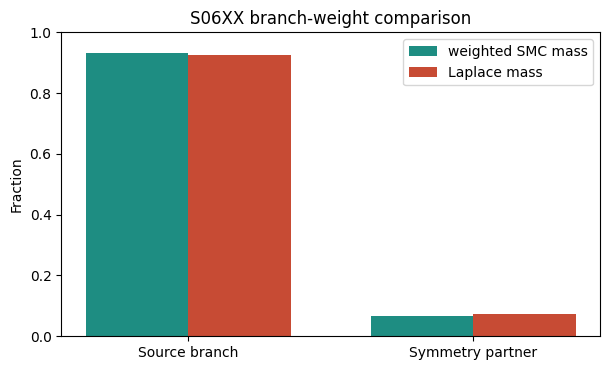

In [24]:
# -------------------------------------------------------------------------
# Compact visual comparison of SMC occupancy and Laplace branch mass.
# -------------------------------------------------------------------------

if all(item["valid"] for item in laplace_results.values()):
    smc_fractions = np.array(
        [
            branch_weight_masses[dominant_branch],
            1.0 - branch_weight_masses[dominant_branch],
        ]
    )
    laplace_fractions = np.array(
        [laplace_source_fraction, laplace_partner_fraction]
    )

    x = np.arange(2)
    width = 0.36

    fig, ax = plt.subplots(figsize=(6.2, 3.8))
    ax.bar(x - width / 2, smc_fractions, width, label="weighted SMC mass", color=MODE_COLORS[0])
    ax.bar(x + width / 2, laplace_fractions, width, label="Laplace mass", color=MODE_COLORS[1])

    ax.set_xticks(x, ["Source branch", "Symmetry partner"])
    ax.set_ylabel("Fraction")
    ax.set_ylim(0.0, 1.0)
    ax.set_title(f"{tilepol} branch-weight comparison")
    ax.legend()

    fig.tight_layout()
    plt.show()


## 12. Power-beam agreement between symmetry branches

The exact conjugate pair produces the same power beam and likelihood to
numerical precision, while the zero-centred phase prior assigns substantially
different density to the two representations. The unequal branch masses are
therefore interpreted primarily as **prior-induced identifiability of an
observationally degenerate solution**, rather than as evidence that the data
distinguish two different beams.

The branch-conditioned posterior means remain useful as a practical check.
Because the phase prior weights the neighbourhoods around the two symmetry
modes differently, their posterior mean beams need not be exactly identical
even though exact transformed pairs are.

We therefore compare

$$
\Delta B =
\mathbb{E}[B\mid S>0]
-
\mathbb{E}[B\mid S<0]
$$

with its posterior uncertainty. Small coherent structure is interpreted as
consistent with different posterior weighting around the two symmetry-related
modes; it is not, by itself, evidence for data-driven symmetry breaking.


In [25]:
complex_branch_beams = []
complex_branch_mean_db = []
complex_branch_std_db = []
complex_branch_residual_db = []
complex_branch_chi2 = []
complex_branch_residual_rms_db = []

for branch_index in range(N_COMPLEX_BRANCHES):
    mask = complex_branch_labels == branch_index
    branch_weights = normalize_weights(complex_weights[mask])

    beams = evaluate_posterior_beams(complex_complex_gains[mask])
    mean_db = weighted_mean(beams, branch_weights)
    std_db = weighted_std(beams, branch_weights)
    residual_db = observed_db - mean_db
    chi2 = float(np.sum((residual_db / observed_sigma_db) ** 2))
    residual_rms_db = float(np.sqrt(np.mean(residual_db**2)))

    complex_branch_beams.append(beams)
    complex_branch_mean_db.append(mean_db)
    complex_branch_std_db.append(std_db)
    complex_branch_residual_db.append(residual_db)
    complex_branch_chi2.append(chi2)
    complex_branch_residual_rms_db.append(residual_rms_db)

    print(
        f"Branch {branch_index}: n={mask.sum():4d}, "
        f"posterior mass={complex_weights[mask].sum():6.2%}, "
        f"median std={np.median(std_db):.4f} dB, "
        f"RMS residual={residual_rms_db:.4f} dB"
    )


Branch 0: n=3764, posterior mass=93.33%, median std=0.0406 dB, RMS residual=2.8899 dB
Branch 1: n= 264, posterior mass= 6.67%, median std=0.0400 dB, RMS residual=2.8903 dB


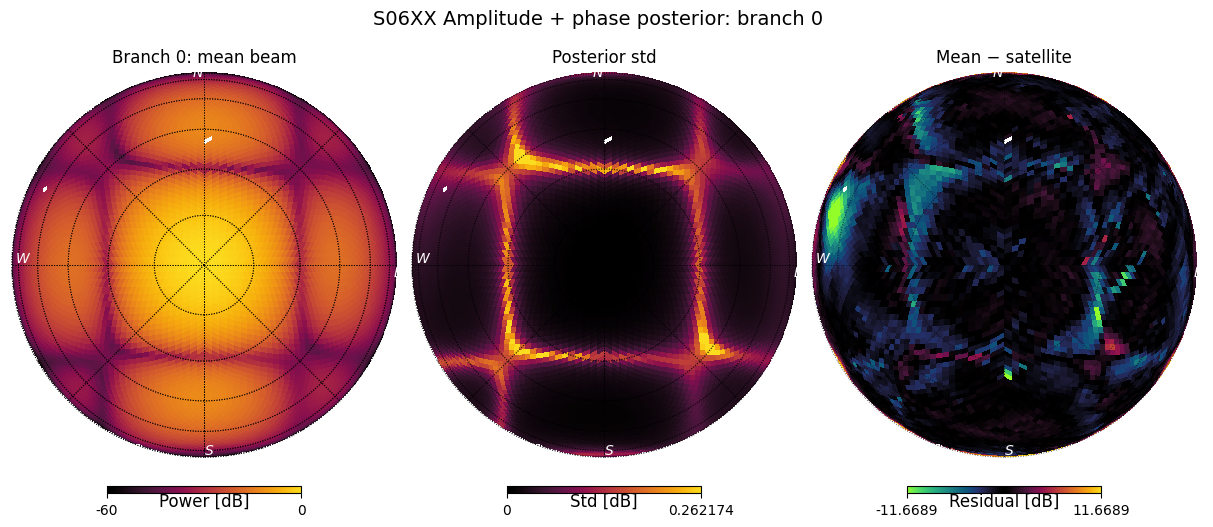

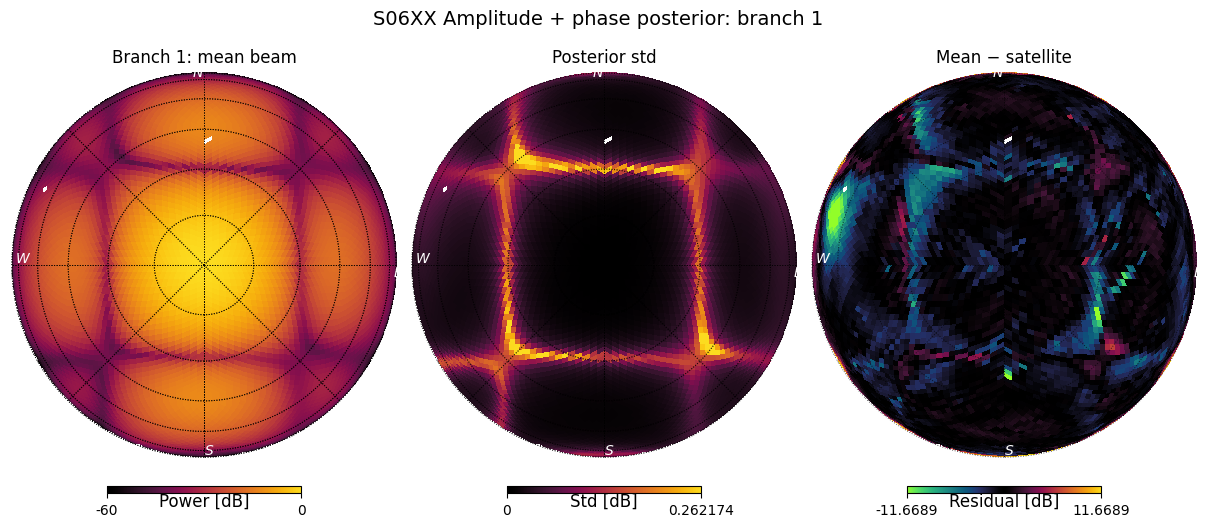

In [26]:
complex_std_limit = np.percentile(np.concatenate(complex_branch_std_db), 99.5)
complex_residual_limit = np.percentile(
    np.abs(np.concatenate(complex_branch_residual_db)), 99
)

for branch_index in range(N_COMPLEX_BRANCHES):
    fig = plt.figure(figsize=(12, 5.4))
    plot_healpix_map(
        comparison_values_to_healpix(complex_branch_mean_db[branch_index]),
        fig=fig,
        sub=(1, 3, 1),
        title=f"Branch {branch_index}: mean beam",
        unit="Power [dB]",
        vmin=-60,
        vmax=0,
        cmap=wfr_lin,
    )
    plot_healpix_map(
        comparison_values_to_healpix(complex_branch_std_db[branch_index]),
        fig=fig,
        sub=(1, 3, 2),
        title="Posterior std",
        unit="Std [dB]",
        vmin=0,
        vmax=complex_std_limit,
        cmap=wfr_lin,
    )
    plot_healpix_map(
        comparison_values_to_healpix(complex_branch_residual_db[branch_index]),
        fig=fig,
        sub=(1, 3, 3),
        title="Mean − satellite",
        unit="Residual [dB]",
        vmin=-complex_residual_limit,
        vmax=complex_residual_limit,
        cmap=wfr_div,
    )
    fig.suptitle(f"{tilepol} Amplitude + phase posterior: branch {branch_index}", fontsize=14, y=0.98)
    plt.savefig(f"{OUTDIR_PATH}/{tilepol}_6_{branch_index}_Amp_Phase_Posterior_Maps.pdf")
    plt.show()


Complex posterior power-beam agreement between branches
---------------------------------
RMS beam difference:       0.0056 dB
Median |beam difference|:  0.0021 dB

Median uncertainty:        0.0571 dB
Median |Δ| / σΔ:           0.040
95th percentile |Δ| / σΔ: 0.094
Pixels within 1σ:          100.0%
Pixels within 2σ:          100.0%


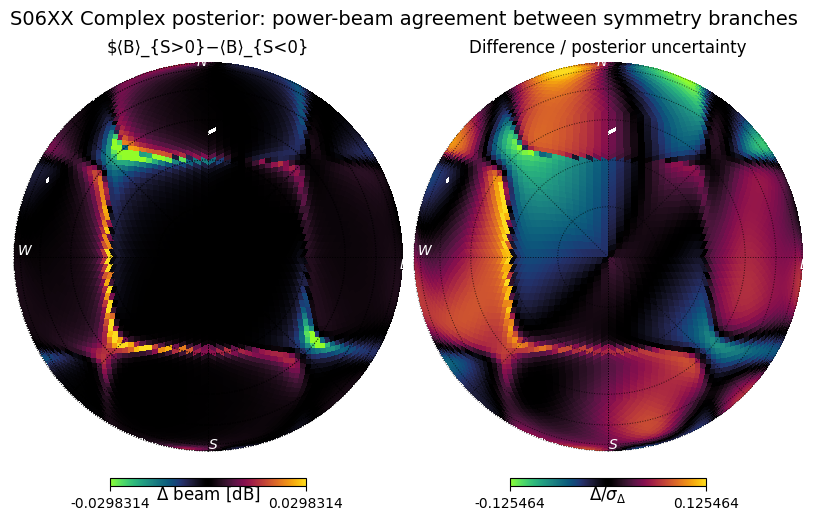

In [27]:
# ---------------------------------------------------------------------
# Statistical comparison of the two complex posterior modes
# ---------------------------------------------------------------------

if N_COMPLEX_BRANCHES != 2:
    raise ValueError("This comparison assumes exactly two complex modes.")

branch_difference_db = (
    complex_branch_mean_db[0]
    - complex_branch_mean_db[1]
)

branch_difference_sigma_db = np.sqrt(
    complex_branch_std_db[0]**2
    + complex_branch_std_db[1]**2
)

branch_difference_z = (
    branch_difference_db
    / branch_difference_sigma_db
)

finite = (
    np.isfinite(branch_difference_db)
    & np.isfinite(branch_difference_sigma_db)
    & (branch_difference_sigma_db > 0)
)

delta = branch_difference_db[finite]
sigma_delta = branch_difference_sigma_db[finite]
z = branch_difference_z[finite]

print("Complex posterior power-beam agreement between branches")
print("---------------------------------")
print(f"RMS beam difference:       {np.sqrt(np.mean(delta**2)):.4f} dB")
print(f"Median |beam difference|:  {np.median(np.abs(delta)):.4f} dB")
print()
print(f"Median uncertainty:        {np.median(sigma_delta):.4f} dB")
print(f"Median |Δ| / σΔ:           {np.median(np.abs(z)):.3f}")
print(f"95th percentile |Δ| / σΔ: {np.percentile(np.abs(z), 95):.3f}")
print(f"Pixels within 1σ:          {np.mean(np.abs(z) < 1):.1%}")
print(f"Pixels within 2σ:          {np.mean(np.abs(z) < 2):.1%}")


# ---------------------------------------------------------------------
# Maps
# ---------------------------------------------------------------------

difference_limit = np.percentile(np.abs(delta), 99.5)
# z_limit = max(1, np.percentile(np.abs(z), 99.5))
z_limit = np.percentile(np.abs(z), 99.5)

fig = plt.figure(figsize=(8, 5.2))

plot_healpix_map(
    comparison_values_to_healpix(branch_difference_db),
    fig=fig,
    sub=(1, 2, 1),
    title="$⟨B⟩_{S>0}−⟨B⟩_{S<0}",
    unit=r"$\Delta$ beam [dB]",
    vmin=-difference_limit,
    vmax=difference_limit,
    # vmin=-0.05,
    # vmax=0.05,
    cmap=wfr_div,
)

plot_healpix_map(
    comparison_values_to_healpix(branch_difference_z),
    fig=fig,
    sub=(1, 2, 2),
    title=r"Difference / posterior uncertainty",
    unit=r"$\Delta / \sigma_\Delta$",
    vmin=-z_limit,
    vmax=z_limit,
    # vmin=-0.5,
    # vmax=0.5,
    cmap=wfr_div,
)

fig.suptitle(
    f"{tilepol} Complex posterior: power-beam agreement between symmetry branches",
    fontsize=14,
    y=1.0,
)

plt.savefig(f"{OUTDIR_PATH}/{tilepol}_7_Complex_Posterior_Branch_Agreement.pdf")

plt.show()


## 13. Primary-branch complex posterior

The full complex posterior is retained when discussing symmetry-branch masses,
branch-conditioned beam predictions, and model comparison. For reporting the
latent dipole amplitudes and phases themselves, however, we condition on the
dominant symmetry branch rather than folding the secondary branch onto it.

This avoids constructing a synthetic merged posterior under the assumption
that the two branch-conditioned distributions are exact transformed copies.
The secondary branch remains scientifically relevant and is analysed above;
the primary branch is simply used as the representative latent-gain solution.

For cross-run or temporal comparisons, the conjugate-rotation map can still be
used to **align** solutions onto a common reference branch when necessary.

In [28]:
positive_mass = complex_weights[positive].sum()
negative_mass = complex_weights[negative].sum()

if positive_mass >= negative_mass:
    primary = positive
    secondary = negative
    primary_sign = +1
else:
    primary = negative
    secondary = positive
    primary_sign = -1

primary_weights = normalize_weights(
    complex_weights[primary]
)

primary_gains = np.asarray(
    complex_complex_gains[primary]
)

primary_amplitudes = np.abs(primary_gains)

primary_phases_rad = np.angle(
    primary_gains
    * np.exp(-1j * np.angle(primary_gains[:, 0]))[:, None]
)

print("Primary complex symmetry branch")
print("-------------------------------")
print(
    f"Primary branch:          "
    f"S {'>' if primary_sign > 0 else '<'} 0"
)
print(
    f"Primary posterior mass:  "
    f"{complex_weights[primary].sum():.3%}"
)
print(
    f"Secondary mass:          "
    f"{complex_weights[secondary].sum():.3%}"
)
print(
    f"Primary particles:       "
    f"{primary.sum()}/{primary.size}"
)

Primary complex symmetry branch
-------------------------------
Primary branch:          S > 0
Primary posterior mass:  93.334%
Secondary mass:          6.666%
Primary particles:       3764/4028


### Primary-branch dipole-gain summary

These summaries describe

$$
p(g\mid d,\;S=S_{\rm primary}),
$$

not a folded mixture over both branches.

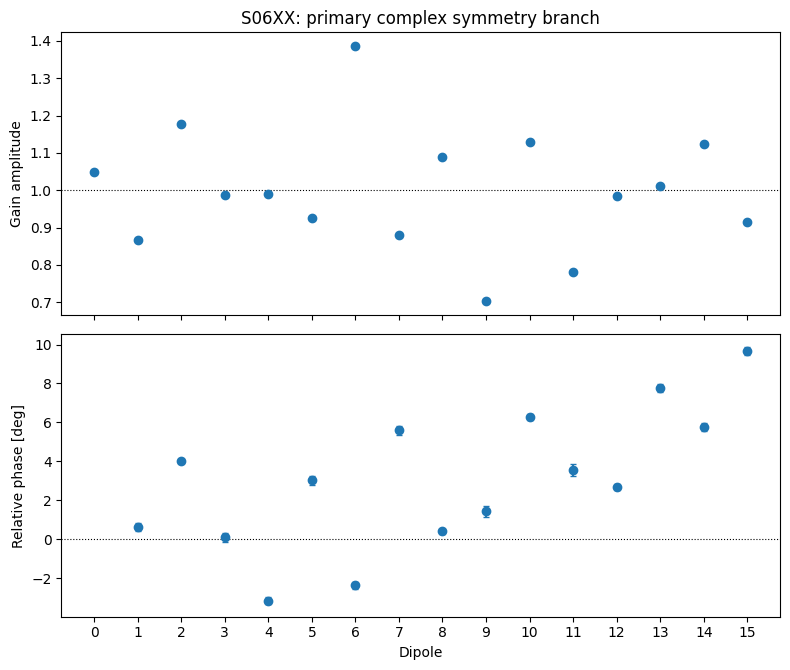

In [29]:
primary_amp_q16, primary_amp_median, primary_amp_q84 = weighted_quantile(
    primary_amplitudes,
    [0.16, 0.50, 0.84],
    primary_weights,
)

primary_phase_mean_rad, primary_phase_std_rad = weighted_circular_mean_std(
    primary_phases_rad[:, 1:],
    primary_weights,
)

primary_phase_mean_deg = np.rad2deg(
    primary_phase_mean_rad
)
primary_phase_std_deg = np.rad2deg(
    primary_phase_std_rad
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 6.8),
    sharex=True,
)

axes[0].errorbar(
    dipoles,
    primary_amp_median,
    yerr=np.vstack(
        [
            primary_amp_median - primary_amp_q16,
            primary_amp_q84 - primary_amp_median,
        ]
    ),
    fmt="o",
    capsize=2,
)

axes[0].axhline(
    1.0,
    color="black",
    ls=":",
    lw=0.8,
)

axes[0].set_ylabel("Gain amplitude")
axes[0].set_title(
    f"{tilepol}: primary complex symmetry branch"
)

axes[1].errorbar(
    dipoles[1:],
    primary_phase_mean_deg,
    yerr=primary_phase_std_deg,
    fmt="o",
    capsize=2,
)

axes[1].axhline(
    0.0,
    color="black",
    ls=":",
    lw=0.8,
)

axes[1].set_xlabel("Dipole")
axes[1].set_ylabel("Relative phase [deg]")
axes[1].set_xticks(dipoles)

fig.tight_layout()
plt.show()

### Selected primary-branch pairwise marginals

We retain selected pairwise marginals rather than full corner plots or
correlation matrices. The goal is to show representative covariance structure
within the physically reported branch without overwhelming the analysis.

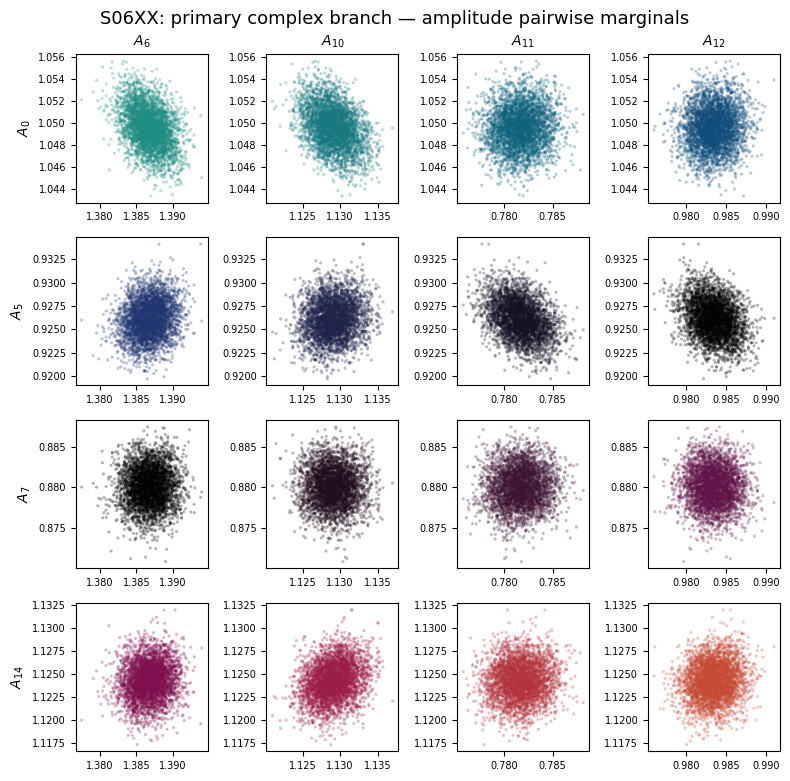

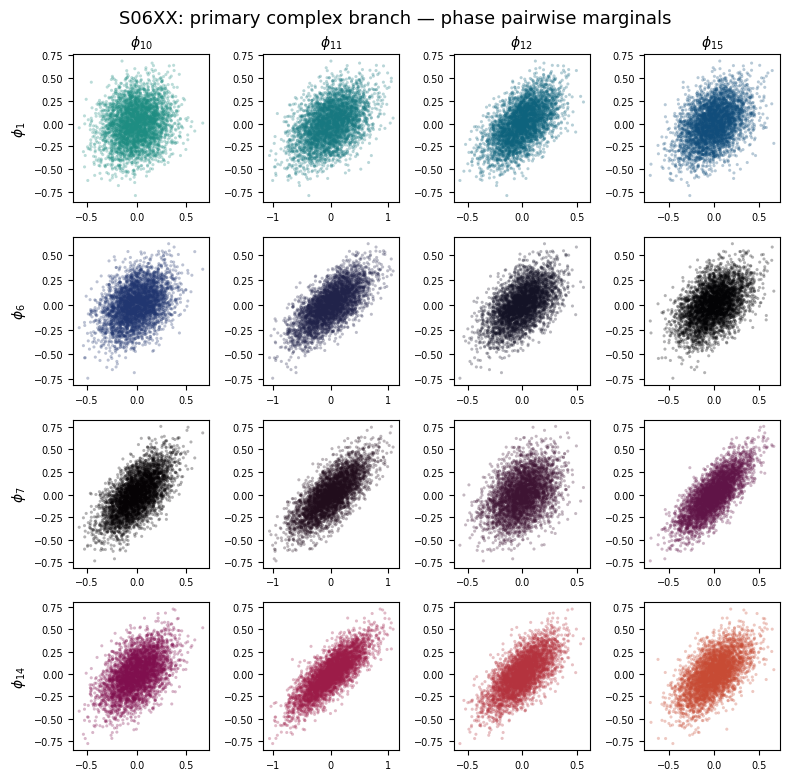

In [30]:
plot_cross_pairwise_marginals(
    primary_amplitudes,
    complex_amplitude_parameter_labels,
    group_size=4,
    seed=69,
    title=(
        f"{tilepol}: primary complex branch — "
        "amplitude pairwise marginals"
    ),
    outpath=(
        OUTDIR_PATH
        / f"{tilepol}_8_0_Primary_Complex_Amplitude_Pairwise.pdf"
    ),
)

primary_phase_center = weighted_circular_mean(
    primary_phases_rad[:, 1:],
    primary_weights,
)

primary_phase_offsets_deg = np.rad2deg(
    np.angle(
        np.exp(
            1j
            * (
                primary_phases_rad[:, 1:]
                - primary_phase_center[None, :]
            )
        )
    )
)

plot_cross_pairwise_marginals(
    primary_phase_offsets_deg,
    complex_phase_parameter_labels,
    group_size=4,
    seed=69,
    title=(
        f"{tilepol}: primary complex branch — "
        "phase pairwise marginals"
    ),
    outpath=(
        OUTDIR_PATH
        / f"{tilepol}_8_1_Primary_Complex_Phase_Pairwise.pdf"
    ),
)

# Part III — Nominal vs amplitude-only vs complex beam


## 14. Posterior-mean beams on the likelihood pixels


In [31]:
amplitude_beams_db = evaluate_posterior_beams(
    amplitude_complex_gains
)
complex_beams_db = evaluate_posterior_beams(
    complex_complex_gains
)

amplitude_model_db = weighted_mean(
    amplitude_beams_db,
    amplitude_weights,
)
complex_model_db = weighted_mean(
    complex_beams_db,
    complex_weights,
)

amplitude_model_std_db = weighted_std(
    amplitude_beams_db,
    amplitude_weights,
)
complex_model_std_db = weighted_std(
    complex_beams_db,
    complex_weights,
)

print(
    "Median posterior beam uncertainty [dB]:",
    f"amplitude={np.median(amplitude_model_std_db):.4f},",
    f"complex={np.median(complex_model_std_db):.4f}",
)

Median posterior beam uncertainty [dB]: amplitude=0.0290, complex=0.0406


## 15. Fit and model-comparison metrics


In [32]:
N_DATA = comparison_indices.size


nominal_residual_db = nominal_model_db - observed_db
amplitude_residual_db = amplitude_model_db - observed_db
complex_residual_db = complex_model_db - observed_db

nominal_chi2 = float(np.sum((nominal_residual_db / observed_sigma_db) ** 2))
amplitude_chi2 = float(np.sum((amplitude_residual_db / observed_sigma_db) ** 2))
complex_chi2 = float(np.sum((complex_residual_db / observed_sigma_db) ** 2))

k_nominal = 0
k_amplitude = int(amplitude_result["latent_dim"])
k_complex = int(complex_result["latent_dim"])

nominal_reduced_chi2 = nominal_chi2 / (N_DATA - k_nominal)
amplitude_reduced_chi2 = amplitude_chi2 / (N_DATA - k_amplitude)
complex_reduced_chi2 = complex_chi2 / (N_DATA - k_complex)

nominal_rms_db = float(np.sqrt(np.mean(nominal_residual_db**2)))
amplitude_rms_db = float(np.sqrt(np.mean(amplitude_residual_db**2)))
complex_rms_db = float(np.sqrt(np.mean(complex_residual_db**2)))

nominal_log_likelihood = float(nominal_result["log_likelihood"])
amplitude_log_likelihood_best = float(amplitude_result["best_log_likelihood"])
complex_log_likelihood_best = float(complex_result["best_log_likelihood"])

nominal_bic = float(nominal_result["bic"])
amplitude_bic = float(amplitude_result["bic"])
complex_bic = float(complex_result["bic"])

print("Final model comparison")
print("----------------------")
print(
    f"{'Model':14s} {'k':>4s} {'RMS [dB]':>11s} {'chi2_red':>11s} "
    f"{'logL':>14s} {'BIC':>14s} {'Delta BIC':>14s}"
)

for name, k, rms, reduced_chi2, log_likelihood, bic in (
    ("Nominal", k_nominal, nominal_rms_db, nominal_reduced_chi2, nominal_log_likelihood, nominal_bic),
    ("Amplitude", k_amplitude, amplitude_rms_db, amplitude_reduced_chi2, amplitude_log_likelihood_best, amplitude_bic),
    ("Amp + phase", k_complex, complex_rms_db, complex_reduced_chi2, complex_log_likelihood_best, complex_bic),
):
    print(
        f"{name:14s} {k:4d} {rms:11.4f} {reduced_chi2:11.3f} "
        f"{log_likelihood:14.1f} {bic:14.1f} {bic - nominal_bic:14.1f}"
    )

print()
print("Pairwise Delta BIC")
print("------------------")
print(f"Amplitude - nominal:   {amplitude_bic - nominal_bic:.1f}")
print(f"Complex - nominal:     {complex_bic - nominal_bic:.1f}")
print(f"Complex - amplitude:   {complex_bic - amplitude_bic:.1f}")

print()
print("SMC evidence comparison")
print("-----------------------")
amplitude_logz = float(amplitude_result["log_evidence"])
complex_logz = float(complex_result["log_evidence"])
print(f"log Z amplitude:        {amplitude_logz:.3f}")
print(f"log Z complex:          {complex_logz:.3f}")
print(f"Delta log Z (C - A):    {complex_logz - amplitude_logz:+.3f}")
print(
    "Interpret Delta log Z only after checking seed/particle-count "
    "stability of the SMC evidence estimate."
)


Final model comparison
----------------------
Model             k    RMS [dB]    chi2_red           logL            BIC      Delta BIC
Nominal           0      7.8894     665.179     -2019627.1      4039254.2            0.0
Amplitude        15      2.9451      55.159       -41052.6        82235.9     -3957018.4
Amp + phase      30      2.8900      51.108       -37068.2        74397.7     -3964856.6

Pairwise Delta BIC
------------------
Amplitude - nominal:   -3957018.4
Complex - nominal:     -3964856.6
Complex - amplitude:   -7838.2

SMC evidence comparison
-----------------------
log Z amplitude:        -41132.088
log Z complex:          -37214.942
Delta log Z (C - A):    +3917.147
Interpret Delta log Z only after checking seed/particle-count stability of the SMC evidence estimate.


## 16. Beam and residual comparison


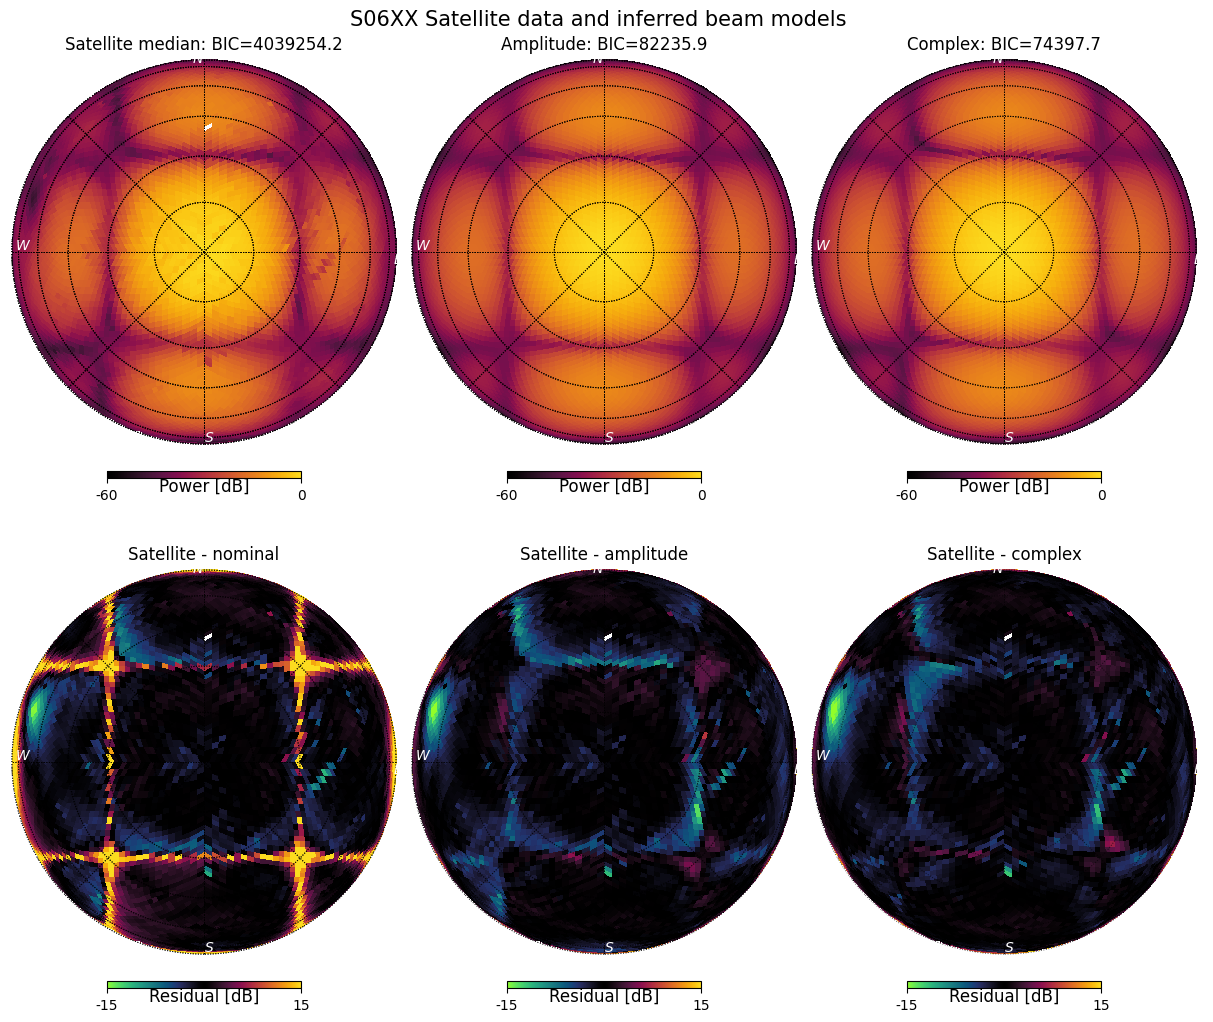

In [33]:
# ---------------------------------------------------------------------
# Full visible-sky model beams for plotting only
#
# Statistical metrics above still use the canonical comparison_indices.
# Here we evaluate the fitted beams over the entire visible hemisphere
# so that likelihood-mask holes do not appear in the figures.
# ---------------------------------------------------------------------

@jax.jit
def predict_visible_beam_db(
    dipole_gains_pol,
):
    fixed = jnp.ones(
        N_DIPOLES,
        dtype=jnp.complex64,
    )

    dipole_gains_pol = dipole_gains_pol.astype(
        jnp.complex64
    )

    dipole_gains = (
        jnp.stack(
            [
                dipole_gains_pol,
                fixed,
            ]
        )
        if POL == 0
        else jnp.stack(
            [
                fixed,
                dipole_gains_pol,
            ]
        )
    )

    power = aee.power(
        az_rad=az_visible,
        za_rad=za_visible,
        dipole_gains=dipole_gains,
        normalize=True,
    )[POL]

    power = jnp.maximum(
        power,
        jnp.finfo(power.dtype).tiny,
    )

    return 10 * jnp.log10(power)


predict_visible_beam_batch_db = jax.jit(
    jax.vmap(
        predict_visible_beam_db,
        in_axes=0,
    )
)


# ---------------------------------------------------------------------
# Evaluate posterior beams over the full weighted posterior.
# ---------------------------------------------------------------------

def evaluate_visible_beams(dipole_gains, batch_size=256):
    batches = []

    for start in range(0, dipole_gains.shape[0], batch_size):
        stop = min(
            start + batch_size,
            dipole_gains.shape[0],
        )

        batch = predict_visible_beam_batch_db(
            jnp.asarray(
                dipole_gains[
                    start:stop
                ],
                dtype=jnp.complex64,
            )
        )

        batch.block_until_ready()

        batches.append(
            np.asarray(
                batch,
                dtype=float,
            )
        )

    return np.concatenate(batches, axis=0)


amplitude_visible_beams_db = evaluate_visible_beams(
    amplitude_complex_gains
)

complex_visible_beams_db = evaluate_visible_beams(
    complex_complex_gains
)

amplitude_visible_mean_db = weighted_mean(
    amplitude_visible_beams_db,
    amplitude_weights,
)

complex_visible_mean_db = weighted_mean(
    complex_visible_beams_db,
    complex_weights,
)


# ---------------------------------------------------------------------
# Nominal model over the complete visible hemisphere.
# ---------------------------------------------------------------------

nominal_visible_db = np.asarray(
    predict_visible_beam_db(
        jnp.ones(
            N_DIPOLES,
            dtype=jnp.complex64,
        )
    ),
    dtype=float,
)


# ---------------------------------------------------------------------
# Embed the visible model vectors into full HEALPix maps.
# ---------------------------------------------------------------------

nominal_beam_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

amplitude_beam_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

complex_beam_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

nominal_beam_map[
    visible
] = nominal_visible_db

amplitude_beam_map[
    visible
] = amplitude_visible_mean_db

complex_beam_map[
    visible
] = complex_visible_mean_db


# ---------------------------------------------------------------------
# Residual maps for visualization.
#
# These use every finite satellite pixel above the horizon, not merely
# the stricter likelihood comparison mask.
# ---------------------------------------------------------------------

plot_data_mask = (
    visible
    & np.isfinite(
        data_map
    )
)

nominal_residual_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

amplitude_residual_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

complex_residual_map = np.full(
    N_PIXELS,
    np.nan,
    dtype=float,
)

nominal_residual_map[
    plot_data_mask
] = (
    data_map[
        plot_data_mask
    ]
    - nominal_beam_map[
        plot_data_mask
    ]
)

amplitude_residual_map[
    plot_data_mask
] = (
    data_map[
        plot_data_mask
    ]
    - amplitude_beam_map[
        plot_data_mask
    ]
)

complex_residual_map[
    plot_data_mask
] = (
    data_map[
        plot_data_mask
    ]
    - complex_beam_map[
        plot_data_mask
    ]
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 10.2)
)

# Satellite data in the upper-left panel.
plot_healpix_map(
    data_map,
    fig=fig,
    sub=(2, 3, 1),
    title=f"Satellite median: BIC={nominal_bic:.1f}",
    unit="Power [dB]",
    vmin=-60,
    vmax=0,
    cmap=wfr_lin,
)

plot_healpix_map(
    amplitude_beam_map,
    fig=fig,
    sub=(2, 3, 2),
    title=f"Amplitude: BIC={amplitude_bic:.1f}",
    unit="Power [dB]",
    vmin=-60,
    vmax=0,
    cmap=wfr_lin,
)

plot_healpix_map(
    complex_beam_map,
    fig=fig,
    sub=(2, 3, 3),
    title=f"Complex: BIC={complex_bic:.1f}",
    unit="Power [dB]",
    vmin=-60,
    vmax=0,
    cmap=wfr_lin,
)

for column, title, residual_map in (
    (
        1,
        "Satellite - nominal",
        nominal_residual_map,
    ),
    (
        2,
        "Satellite - amplitude",
        amplitude_residual_map,
    ),
    (
        3,
        "Satellite - complex",
        complex_residual_map,
    ),
):
    plot_healpix_map(
        residual_map,
        fig=fig,
        sub=(2, 3, 3 + column),
        title=title,
        unit="Residual [dB]",
        vmin=-15,
        vmax=15,
        cmap=wfr_div,
    )

fig.suptitle(f"{tilepol} Satellite data and inferred beam models", fontsize=15, y=1)
plt.savefig(f"{OUTDIR_PATH}/{tilepol}_9_Amp_Complex_Model_Comparison.pdf")

plt.show()

# Part IV — Temporal robustness

The detailed chunk-construction and anomalous single-pass-pixel debugging
sequence is intentionally omitted here; those quality cuts now belong to the
production pipeline.

This section asks two scientific questions:

1. is the inferred beam stable across independent 20-day subsets?
2. is the preferred symmetry branch and the representative primary-branch
   latent solution stable across those subsets?


In [34]:
import pandas as pd

In [35]:
chunk_dir = Path("../data/smc_nuts_blackjax/soft_laplace/S06XX/")

chunk_files = sorted(
    chunk_dir.glob(
        "S06XX_rf0XX_passes_S06XX_N4028_S314159_C20_I*_AMP_COMPLEX_smc_blackjax.pkl"
    )
)

if len(chunk_files) != 4:
    raise ValueError(
        f"Expected 4 chunk files, found {len(chunk_files)}:\n"
        + "\n".join(str(p) for p in chunk_files)
    )

chunk_results = {}

for path in chunk_files:
    with path.open("rb") as f:
        result = pickle.load(f)

    i = int(result["metadata"]["chunk_index"])
    chunk_results[i] = result

print("Loaded chunks:", sorted(chunk_results))

Loaded chunks: [0, 1, 2, 3]


In [36]:
rows = []

for i, result in chunk_results.items():
    meta = result["metadata"]

    row = {
        "chunk": i,
        "pixels": meta["n_comparison_pixels"],
        "masked": meta["n_single_pass_masked"],
        "nominal BIC": result["nominal"]["bic"],
    }

    for kind in ("amplitude", "complex"):
        fit = result[kind]

        row[f"{kind} stages"] = len(
            fit["stage_diagnostics"]["stage"]
        )
        row[f"{kind} runtime [min]"] = (
            fit["runtime_seconds"] / 60
        )
        row[f"{kind} logZ"] = fit["log_evidence"]
        row[f"{kind} BIC"] = fit["bic"]

    rows.append(row)

chunk_summary = (
    pd.DataFrame(rows)
    .sort_values("chunk")
    .reset_index(drop=True)
)

display(
    chunk_summary.style.format({
        "nominal BIC": "{:.1f}",
        "amplitude BIC": "{:.1f}",
        "complex BIC": "{:.1f}",
        "amplitude logZ": "{:.1f}",
        "complex logZ": "{:.1f}",
        "amplitude runtime [min]": "{:.1f}",
        "complex runtime [min]": "{:.1f}",
    })
)

,chunk,pixels,masked,nominal BIC,amplitude stages,amplitude runtime [min],amplitude logZ,amplitude BIC,complex stages,complex runtime [min],complex logZ,complex BIC
0,0,5523,6,2346924.5,59,30.5,-34651.7,69279.8,76,65.7,-32749.0,65484.4
1,1,5329,4,2516341.2,58,32.8,-34293.4,68564.8,77,73.6,-31893.3,63765.9
2,2,5204,4,1590032.4,58,30.9,-29698.5,59375.6,76,72.1,-27510.3,55000.8
3,3,5011,9,1697592.5,58,28.3,-29782.5,59542.3,76,61.8,-27652.8,55282.1


## 17. Temporal stability of symmetry-branch masses


In [37]:
chunk_branch_rows = []

for chunk_index in sorted(chunk_results):
    fit = chunk_results[chunk_index]["complex"]

    weights = normalize_weights(
        np.asarray(fit["weights"], dtype=float).ravel()
    )
    gains = np.asarray(
        fit["posterior_sites"]["dipole_gain_complex"]
    )

    S = symmetry_statistic_many(gains)

    chunk_branch_rows.append(
        {
            "chunk": chunk_index,
            "mass S>0": weights[S > 0].sum(),
            "mass S<0": weights[S < 0].sum(),
            "min |S|": np.min(np.abs(S)),
        }
    )

chunk_branch_table = pd.DataFrame(chunk_branch_rows)

display(
    chunk_branch_table.style.format(
        {
            "mass S>0": "{:.3f}",
            "mass S<0": "{:.3f}",
            "min |S|": "{:.3e}",
        }
    )
)

,chunk,mass S>0,mass S<0,min |S|
0,0,0.783,0.217,1.089e-06
1,1,0.928,0.072,1.247e-06
2,2,0.853,0.147,9.650e-07
3,3,0.763,0.237,9.927e-07


## 18. Amplitude-only consistency across 20-day chunks


In [38]:
def normalized_weights(fit):
    w = np.asarray(fit["weights"], dtype=float).ravel()
    return w / w.sum()


def weighted_mean_std(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    mean = np.sum(w[:, None] * x, axis=0)
    var = np.sum(
        w[:, None] * (x - mean[None, :])**2,
        axis=0,
    )

    return mean, np.sqrt(var)

In [39]:
amp_chunk_stats = {}

for i, result in chunk_results.items():
    fit = result["amplitude"]
    w = normalized_weights(fit)

    amplitudes = np.asarray(
        fit["posterior_sites"]["dipole_gain_amplitude"],
        dtype=float,
    )

    mean, std = weighted_mean_std(
        amplitudes,
        w,
    )

    amp_chunk_stats[i] = {
        "mean": mean,
        "std": std,
    }

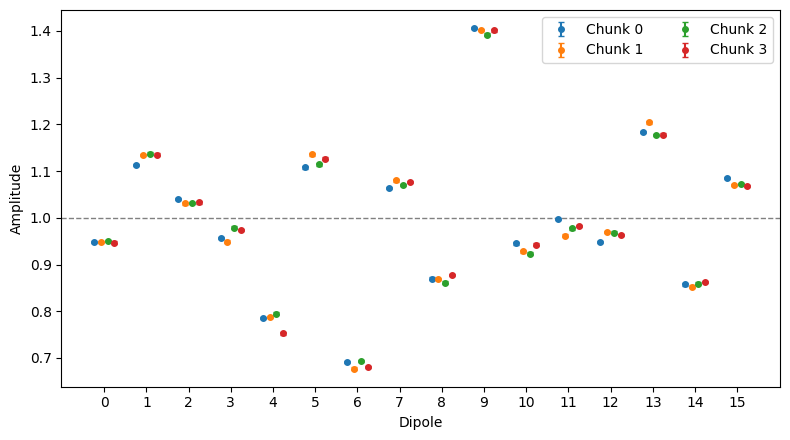

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))

dipoles = np.arange(16)

offsets = np.linspace(-0.24, 0.24, 4)

for offset, i in zip(offsets, sorted(amp_chunk_stats)):
    stats = amp_chunk_stats[i]

    ax.errorbar(
        dipoles + offset,
        stats["mean"],
        yerr=stats["std"],
        fmt="o",
        ms=4,
        capsize=2,
        label=f"Chunk {i}",
    )

ax.axhline(
    1.0,
    ls="--",
    lw=1,
    color="0.5",
)

ax.set_xlabel("Dipole")
ax.set_ylabel("Amplitude")
ax.set_xticks(dipoles)
ax.legend(ncols=2)

fig.tight_layout()
plt.savefig(
    f"{OUTDIR_PATH}/{tilepol}_10_Amp_Posterior_Chunks.pdf"
)
plt.show()

## 19. Symmetry-aligned primary complex gains across chunks

Latent gain summaries are compared using the **primary posterior branch** from
each temporal subset. We do not fold both branches together. If a chunk's
primary branch has the opposite symmetry sign to the chosen reference
orientation, that primary branch alone is transformed onto the common
\(S>0\) orientation before comparison.

For the current soft-Laplace runs all four chunks already prefer \(S>0\), so
the alignment is effectively only a consistency check.


In [41]:
# -------------------------------------------------------------------------
# Select each chunk's primary branch and, only if necessary, align that
# primary branch onto a common S > 0 orientation.
# -------------------------------------------------------------------------

complex_aligned_primary = {}

for chunk_index in sorted(chunk_results):

    fit = chunk_results[chunk_index]["complex"]

    weights_full = np.asarray(
        fit["weights"],
        dtype=float,
    ).ravel()
    weights_full /= weights_full.sum()

    gains_full = np.asarray(
        fit["posterior_sites"]["dipole_gain_complex"]
    )

    S_full = symmetry_statistic_many(
        gains_full
    )

    mass_positive = weights_full[S_full > 0].sum()
    mass_negative = weights_full[S_full < 0].sum()

    if mass_positive >= mass_negative:
        primary_mask = S_full > 0
        primary_sign = +1
    else:
        primary_mask = S_full < 0
        primary_sign = -1

    gains = gains_full[primary_mask].copy()
    weights = weights_full[primary_mask]
    weights /= weights.sum()

    transformed = False

    if primary_sign < 0:
        gains = np.asarray([
            conjugate_rotate_gains(g)
            for g in gains
        ])
        transformed = True

    S_aligned = symmetry_statistic_many(
        gains
    )

    complex_aligned_primary[chunk_index] = {
        "gains": gains,
        "weights": weights,
        "primary_sign_before": primary_sign,
        "primary_mass": max(
            mass_positive,
            mass_negative,
        ),
        "transformed": transformed,
        "S_aligned": S_aligned,
    }

    print(
        f"Chunk {chunk_index}: "
        f"primary mass={max(mass_positive, mass_negative):.3f}; "
        f"primary sign={'+' if primary_sign > 0 else '-'}; "
        f"aligned={'yes' if transformed else 'already S>0'}; "
        f"min S after={S_aligned.min():+.3e}"
    )


Chunk 0: primary mass=0.783; primary sign=+; aligned=already S>0; min S after=+1.089e-06
Chunk 1: primary mass=0.928; primary sign=+; aligned=already S>0; min S after=+1.247e-06
Chunk 2: primary mass=0.853; primary sign=+; aligned=already S>0; min S after=+9.650e-07
Chunk 3: primary mass=0.763; primary sign=+; aligned=already S>0; min S after=+9.984e-07


In [42]:
for chunk_index, aligned in complex_aligned_primary.items():

    gains = aligned["gains"]

    aligned["amplitudes"] = np.abs(gains)

    aligned["phases_rad"] = np.angle(
        gains
        * np.exp(
            -1j * np.angle(gains[:, 0])
        )[:, None]
    )

    aligned["phases_deg"] = np.rad2deg(
        aligned["phases_rad"]
    )


In [43]:
complex_chunk_stats = {}

for chunk_index, aligned in complex_aligned_primary.items():

    amp_mean = weighted_mean(
        aligned["amplitudes"],
        aligned["weights"],
    )
    amp_std = weighted_std(
        aligned["amplitudes"],
        aligned["weights"],
    )

    phase_mean, phase_std = weighted_circular_mean_std(
        aligned["phases_rad"],
        aligned["weights"],
    )

    complex_chunk_stats[chunk_index] = {
        "amp_mean": amp_mean,
        "amp_std": amp_std,
        "phase_mean_rad": phase_mean,
        "phase_std_rad": phase_std,
    }


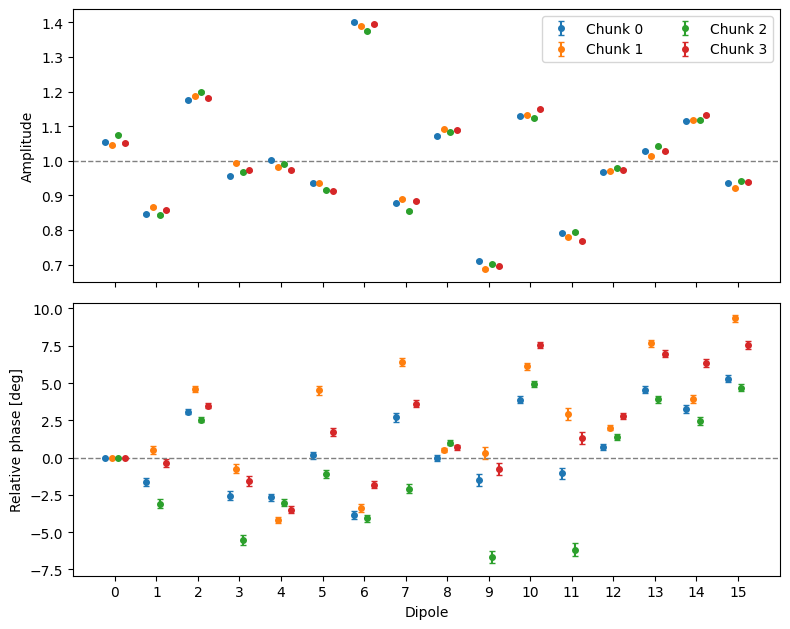

In [44]:
fig, (ax_amp, ax_phase) = plt.subplots(
    2,
    1,
    figsize=(8, 6.4),
    sharex=True,
)

dipoles = np.arange(16)
offsets = np.linspace(-0.24, 0.24, 4)

for offset, chunk_index in zip(
    offsets,
    sorted(complex_chunk_stats),
):

    stats = complex_chunk_stats[chunk_index]

    ax_amp.errorbar(
        dipoles + offset,
        stats["amp_mean"],
        yerr=stats["amp_std"],
        fmt="o",
        ms=4,
        capsize=2,
        label=f"Chunk {chunk_index}",
    )

    ax_phase.errorbar(
        dipoles + offset,
        np.rad2deg(stats["phase_mean_rad"]),
        yerr=np.rad2deg(stats["phase_std_rad"]),
        fmt="o",
        ms=4,
        capsize=2,
    )

ax_amp.axhline(
    1.0,
    color="0.5",
    ls="--",
    lw=1,
)

ax_phase.axhline(
    0.0,
    color="0.5",
    ls="--",
    lw=1,
)

ax_amp.set_ylabel("Amplitude")
ax_phase.set_ylabel("Relative phase [deg]")
ax_phase.set_xlabel("Dipole")

ax_phase.set_xticks(dipoles)

ax_amp.legend(
    ncols=2,
)

fig.tight_layout()
plt.savefig(
    f"{OUTDIR_PATH}/{tilepol}_11_Complex_Posterior_Chunks.pdf"
)
plt.show()

## 20. Full-hemisphere beam robustness across chunks

Unlike the latent-gain comparison above, the beam is an observable and is
therefore summarized from the **full complex posterior**, retaining both
symmetry branches with their SMC weights.


In [45]:
# -------------------------------------------------------------------------
# Full geometric visible hemisphere
#
# This is deliberately independent of data coverage / count maps /
# comparison_indices.
# -------------------------------------------------------------------------

pixel_indices = np.arange(N_PIXELS)
za_hpx, az_hpx = hp.pix2ang(NSIDE, pixel_indices)

hemisphere = za_hpx <= np.pi / 2
hemisphere_indices = np.flatnonzero(hemisphere)

az_hemisphere = jnp.asarray(
    az_hpx[hemisphere],
    dtype=jnp.float32,
)
za_hemisphere = jnp.asarray(
    za_hpx[hemisphere],
    dtype=jnp.float32,
)

print(f"Full sky pixels:       {N_PIXELS}")
print(f"Hemisphere pixels:     {hemisphere_indices.size}")
print(f"Fraction of full sky:  {hemisphere_indices.size / N_PIXELS:.3f}")

Full sky pixels:       12288
Hemisphere pixels:     6208
Fraction of full sky:  0.505


In [46]:
@jax.jit
def predict_hemisphere_beam_db(dipole_gains_pol):
    fixed = jnp.ones(
        N_DIPOLES,
        dtype=jnp.complex64,
    )

    dipole_gains_pol = dipole_gains_pol.astype(
        jnp.complex64
    )

    dipole_gains = (
        jnp.stack([dipole_gains_pol, fixed])
        if POL == 0
        else jnp.stack([fixed, dipole_gains_pol])
    )

    power = aee.power(
        az_rad=az_hemisphere,
        za_rad=za_hemisphere,
        dipole_gains=dipole_gains,
        normalize=True,
    )[POL]

    power = jnp.maximum(
        power,
        jnp.finfo(power.dtype).tiny,
    )

    return 10.0 * jnp.log10(power)


predict_hemisphere_beam_batch_db = jax.jit(
    jax.vmap(
        predict_hemisphere_beam_db,
        in_axes=0,
    )
)


In [47]:
def hemisphere_values_to_healpix(values):
    values = np.asarray(values, dtype=float)

    if values.shape != (hemisphere_indices.size,):
        raise ValueError(
            f"Expected {(hemisphere_indices.size,)}, "
            f"received {values.shape}."
        )

    healpix_map = np.full(
        N_PIXELS,
        np.nan,
        dtype=float,
    )

    healpix_map[hemisphere_indices] = values

    return healpix_map


In [48]:
def weighted_hemisphere_beam_mean_std(
    gains,
    weights,
    batch_size=128,
):
    gains = np.asarray(gains)
    weights = normalize_weights(weights)

    if len(gains) != len(weights):
        raise ValueError(
            "gains and weights must have matching lengths."
        )

    mean_accum = np.zeros(
        hemisphere_indices.size,
        dtype=np.float64,
    )
    second_accum = np.zeros_like(mean_accum)

    for start in range(0, len(gains), batch_size):
        stop = min(
            start + batch_size,
            len(gains),
        )

        beam_batch = predict_hemisphere_beam_batch_db(
            jnp.asarray(
                gains[start:stop],
                dtype=jnp.complex64,
            )
        )

        beam_batch.block_until_ready()

        beam_batch = np.asarray(
            beam_batch,
            dtype=np.float64,
        )

        w = weights[start:stop]

        mean_accum += np.sum(
            w[:, None] * beam_batch,
            axis=0,
        )

        second_accum += np.sum(
            w[:, None] * beam_batch**2,
            axis=0,
        )

    variance = np.maximum(
        second_accum - mean_accum**2,
        0.0,
    )

    return mean_accum, np.sqrt(variance)


In [49]:
complex_chunk_beams = {}

for chunk_index in sorted(chunk_results):

    fit = chunk_results[chunk_index]["complex"]

    gains = np.asarray(
        fit["posterior_sites"]["dipole_gain_complex"]
    )
    weights = normalize_weights(
        np.asarray(
            fit["weights"],
            dtype=float,
        ).ravel()
    )

    print(f"Evaluating chunk {chunk_index}...")

    mean_db, std_db = weighted_hemisphere_beam_mean_std(
        gains,
        weights,
        batch_size=128,
    )

    complex_chunk_beams[chunk_index] = {
        "mean_db": mean_db,
        "std_db": std_db,
    }

    print(
        f"  median posterior std = "
        f"{np.median(std_db):.4f} dB"
    )


Evaluating chunk 0...
  median posterior std = 0.0512 dB
Evaluating chunk 1...
  median posterior std = 0.0491 dB
Evaluating chunk 2...
  median posterior std = 0.0557 dB
Evaluating chunk 3...
  median posterior std = 0.0518 dB


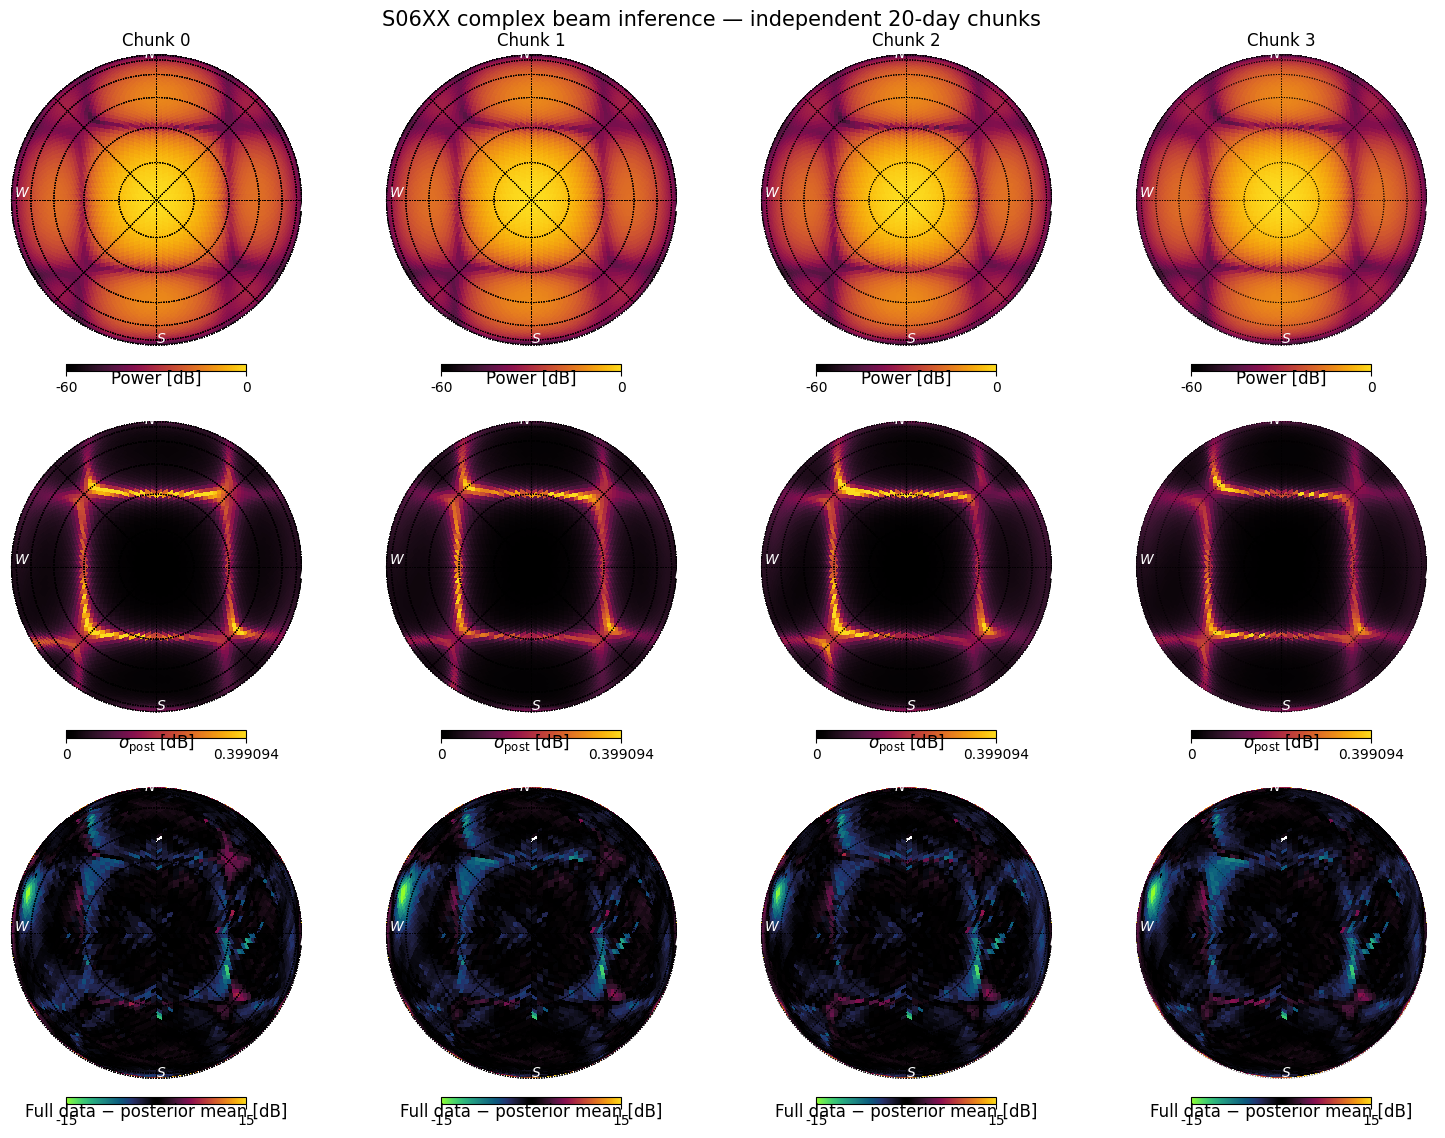

In [50]:
std_limit = max(
    np.percentile(
        complex_chunk_beams[i]["std_db"],
        99.5,
    )
    for i in complex_chunk_beams
)


fig = plt.figure(
    figsize=(15, 11)
)

for col, chunk_index in enumerate(
    sorted(complex_chunk_beams)
):

    mean_map = hemisphere_values_to_healpix(
        complex_chunk_beams[chunk_index]["mean_db"]
    )

    std_map = hemisphere_values_to_healpix(
        complex_chunk_beams[chunk_index]["std_db"]
    )

    # ------------------------------------------------------------------
    # Full-dataset satellite data minus this chunk's posterior mean beam.
    # ------------------------------------------------------------------

    residual_map = np.full(
        N_PIXELS,
        np.nan,
        dtype=float,
    )

    valid_full_data = (
        np.isfinite(full_data_map)
    )

    residual_map[valid_full_data] = (
        full_data_map[valid_full_data]
        - mean_map[valid_full_data]
    )

    # ------------------------------------------------------------------
    # Row 1: posterior mean inferred from this 20-day chunk
    # ------------------------------------------------------------------

    plot_healpix_map(
        mean_map,
        fig=fig,
        sub=(3, 4, col + 1),
        title=f"Chunk {chunk_index}",
        unit="Power [dB]",
        vmin=-60,
        vmax=0,
        cmap=wfr_lin,
    )

    # ------------------------------------------------------------------
    # Row 2: posterior uncertainty from this 20-day chunk
    # ------------------------------------------------------------------

    plot_healpix_map(
        std_map,
        fig=fig,
        sub=(3, 4, 4 + col + 1),
        title="",
        unit=r"$\sigma_{\rm post}$ [dB]",
        vmin=0,
        vmax=std_limit,
        cmap=wfr_lin,
    )

    # ------------------------------------------------------------------
    # Row 3: complete satellite dataset minus chunk posterior mean
    # ------------------------------------------------------------------

    plot_healpix_map(
        residual_map,
        fig=fig,
        sub=(3, 4, 8 + col + 1),
        title="",
        unit="Full data − posterior mean [dB]",
        vmin=-15,
        vmax=15,
        cmap=wfr_div,
    )

fig.suptitle(
    "S06XX complex beam inference — independent 20-day chunks",
    fontsize=15,
    y=1.02,
)
plt.savefig(
    f"{OUTDIR_PATH}/{tilepol}_12_Complex_Posterior_Maps_Chunks.pdf"
)
plt.show()

In [51]:
full_data_residual_stats = []

for chunk_index in sorted(complex_chunk_beams):

    mean_map = hemisphere_values_to_healpix(
        complex_chunk_beams[chunk_index]["mean_db"]
    )

    valid = (
        np.isfinite(full_data_map)
        & np.isfinite(mean_map)
        & (full_data_map > -50)
    )

    residual = (
        full_data_map[valid]
        - mean_map[valid]
    )

    full_data_residual_stats.append({
        "chunk": chunk_index,
        "N": valid.sum(),
        "RMS [dB]": np.sqrt(np.mean(residual**2)),
        "median |residual| [dB]": np.median(np.abs(residual)),
        "mean residual [dB]": np.mean(residual),
        "std residual [dB]": np.std(residual),
    })

full_data_residual_stats = pd.DataFrame(
    full_data_residual_stats
)

display(
    full_data_residual_stats.style.format({
        "RMS [dB]": "{:.3f}",
        "median |residual| [dB]": "{:.3f}",
        "mean residual [dB]": "{:+.3f}",
        "std residual [dB]": "{:.3f}",
    })
)


,chunk,N,RMS [dB],median |residual| [dB],mean residual [dB],std residual [dB]
0,0,5953,2.710,1.034,-0.232,2.700
1,1,5953,2.810,1.003,-0.291,2.794
2,2,5953,2.715,1.042,-0.308,2.698
3,3,5953,2.737,1.065,-0.337,2.716
